# MICrONS Exploratory Data Analysis

This notebook maps out the MICrONS functional dataset and surfaces preprocessing-relevant signals before we apply dimensionality-reduction methods.

Design: see [`docs/specs/2026-04-30-microns-eda-design.md`](docs/specs/2026-04-30-microns-eda-design.md).
We deep-dive on the *median-neuron* session (`7_5`) here so the EDA characterizes a representative recording, not an outlier.

The notebook has four parts:

1. **Part 0**: Setup, constants, sanity check.
2. **Part 1**: Cross-session overview. Identify outlier sessions and justify the deep-dive choice.
3. **Part 2**: Deep-dive on session `7_5`: structure, stimuli, responses, behavior, preprocessing diagnostics.
4. **Part 3**: Takeaways for the dim-reduction phase.

## Part 0: Setup

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import microns_datacleaner as mic

%load_ext autoreload
%autoreload 2

import microns_eda

In [2]:
# Apply the presentation palette + white-background style globally.
# (Defined in /Users/francesca/Desktop/neuro_project/neuro_palette.py.)
from neuro_palette import apply_style
apply_style()

### Constants

- `DATADIR`: directory containing `microns.h5`.
- `DEEP_DIVE_SESSION`: `"7_5"`, the session whose neuron count is closest to the cross-session median (8,194 vs. 8,176).
- `RANDOM_SEED`: used for any sub-sampling step that needs reproducibility.
- `CORRELATION_SUBSAMPLE_N`: number of neurons randomly sub-sampled before computing the neuron × neuron correlation matrix in section 2e. The full ~10k × 10k correlation matrix is slow to compute (~minutes) and adds no information at typical screen resolution; 2,000 keeps the heatmap legible and gives stable correlation estimates with ~40,000 timesteps per pair.

In [3]:
DATADIR = Path(os.environ.get("MICRONS_DATADIR", "../neuroscience"))
DEEP_DIVE_SESSION = "7_5"
RANDOM_SEED = 42
CORRELATION_SUBSAMPLE_N = 2000
FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

np.random.seed(RANDOM_SEED)
sns.set_theme(style="whitegrid", context="notebook")

# H5 path matches what MicronsFunctionalReader and microns_eda.open_h5 expect.
H5_PATH = DATADIR / "functional" / "microns_functional.h5"
print("DATADIR:", DATADIR.resolve())
print("H5 found at expected path:", H5_PATH.exists())

DATADIR: /Users/francesca/Desktop/neuroscience
H5 found at expected path: True


### Data layout check

In [4]:
expected = DATADIR / "functional" / "microns_functional.h5"
if not expected.exists():
    candidates = [
        DATADIR / "microns.h5",
        DATADIR / "microns_functional.h5",
    ]
    source = next((c for c in candidates if c.exists()), None)
    if source is None:
        raise FileNotFoundError(
            f"H5 not found at {expected} or at any of {candidates}. "
            f"Set MICRONS_DATADIR to the directory containing your H5 file."
        )
    expected.parent.mkdir(parents=True, exist_ok=True)
    expected.symlink_to(source.resolve())
    print(f"Created symlink: {expected} -> {source.resolve()}")
else:
    print(f"H5 found at expected path: {expected}")

H5 found at expected path: ../neuroscience/functional/microns_functional.h5


### Sanity check

We verify that:

1. The `MicronsFunctionalReader` constructs without error.
2. We can list sessions through the H5 file (`h5py` fallback path).
3. We can read at least one stim type via the reader.
4. Per-trial pupil and treadmill arrays are accessible (the loaders rely on the `h5py` fallback for these).

**What we're spotting:** an environment problem (missing package, wrong path, corrupted H5) before the EDA runs.

In [5]:
reader = microns_eda.open_dataset(DATADIR)
sessions = microns_eda.list_sessions(DATADIR)
print(f"Sessions: {len(sessions)} ({sessions[0]} ... {sessions[-1]})")

example_hash = reader.get_hashes_by_session(DEEP_DIVE_SESSION)[0]
example_type = reader.get_video_type(example_hash)
print(f"Example trial in {DEEP_DIVE_SESSION}: hash={example_hash} type={example_type}")

trial0 = microns_eda.load_trial(reader, DATADIR, DEEP_DIVE_SESSION, 0)
for k, v in trial0.items():
    if hasattr(v, "shape"):
        print(f"  {k}: shape={v.shape} dtype={v.dtype}")
    else:
        print(f"  {k}: {v!r}")

assert trial0["responses"].ndim == 2
assert trial0["pupil"].shape[0] == 4
assert trial0["treadmill"].ndim == 2
print("\nsanity check passed")

Sessions: 14 (4_7 ... 9_6)
Example trial in 7_5: hash=YLuStB2eXkgOS+Cescsy type=Monet2
  responses: shape=(8194, 113) dtype=float32
  pupil: shape=(4, 113) dtype=float32
  treadmill: shape=(113, 1) dtype=float32
  stim_times: shape=(113,) dtype=float32
  stim_type: 'Monet2'
  condition_hash: 'YLuStB2eXkgOS+Cescsy'

sanity check passed


**Expected output above:** 14 sessions; an example hash with stim type `Clip`, `Monet2`, `Trippy`, or `Unknown`; and per-trial arrays whose shapes match the spec (`responses`: `(n_neurons, n_frames)`; `pupil`: `(4, n_frames)`; `treadmill`: `(n_frames, 1)`).

## Part 1: Cross-session overview

Before deep-diving into one session, we do a sanity-check that the 14 sessions are structurally comparable. For each diagnostic below, we follow the workflow "*what we compute → what an outlier looks like → what it means*".

### 1.1 Sessions summary table

**What we compute:** per session, neuron count, V1/AL/LM/RL counts, trial count, stim type counts, median per-neuron mean and variance, mean pupil diameter, mean treadmill speed, median trial duration.

**What we're spotting:** sessions that don't fit the template (e.g. trial count ≠ 464). They should be excluded.

In [6]:
summary_df = microns_eda.summarize_all_sessions(reader, DATADIR)
summary_df

,n_neurons,n_AL,n_LM,n_RL,n_V1,n_trials,n_Clip,n_Monet2,n_Trippy,n_Unknown,median_per_neuron_mean,median_per_neuron_var,mean_pupil_diameter,mean_treadmill_speed,median_trial_duration
session,,,,,,,,,,,,,,,
4_7,7493,387,983,811,5312,464,384,40,40,0,1.927273,57.060406,51.761351,-0.307408,75
5_6,8592,468,1158,952,6014,464,384,40,40,0,1.070414,21.085900,50.644660,0.005755,75
5_7,8138,403,1066,892,5777,464,384,40,40,0,1.179385,24.721541,31.198829,0.004712,75
6_2,8158,317,978,861,6002,464,384,40,40,0,1.343133,29.670646,34.129890,-0.000642,75
6_4,8221,317,1027,878,5999,464,384,40,40,0,1.187854,26.889683,49.304396,0.003137,75
6_6,7971,287,979,800,5905,464,384,40,40,0,1.228362,28.084067,36.394956,0.008749,75
6_7,7887,305,960,814,5808,464,384,40,40,0,1.406358,33.926815,33.323196,-0.140653,75
7_3,8618,324,1135,850,6309,464,384,40,40,0,1.005361,17.202583,38.207591,-0.000129,75
7_4,11201,575,1534,1367,7725,464,384,40,40,0,0.886731,14.375246,47.920270,-0.048380,75


**Interpretation:**

- **Structurally, the sessions are very consistent.** All 14 have exactly 464 trials, the same stimulus breakdown (384 Clip + 40 Monet2 + 40 Trippy, no Unknown), and the same median trial duration of 75 frames. At the dataset's ~7.5 Hz sampling rate (dt ≈ 0.133 s), that's ≈ 10 s per Clip trial; Monet2/Trippy trials are longer (113 frames ≈ 15 s). Nothing to exclude on structural grounds.

- **V1 dominates everywhere**, with AL/LM/RL present in every session in roughly the same proportions (LM and RL larger than AL). The recording template is the same across sessions.

- **Neuron counts vary a lot (~5k–11k).** This is expected (different fields of view) but the extremes are worth noting:
  - **Session 9_6** is the smallest by far (5130 neurons, roughly half of session 7_4).
  - **Session 7_4** has the most neurons (11201).
- **Behaviour: most mice are essentially stationary.** Treadmill speed is a signed velocity (positive = forward, negative = backward), so what matters is the magnitude. Most sessions sit at |speed| < 0.5, consistent with a stationary head-fixed mouse and normal sensor drift around zero.

  - **Session 9_6 stands out** with |speed| ≈ 1.43, roughly 3× the next-highest session (8_5, ≈ 0.45). Still small in absolute terms (typical sustained running is much larger), but clearly the most active animal in this set. Combined with its low neuron count, 9_6 is a candidate for closer inspection or exclusion.

- **Activity statistics flag session 4_7.** Its median per-neuron mean (1.93) and variance (57.1) are about 2× higher than the rest, which cluster around mean ~1.0–1.4 and var ~15–35. Could be genuine (more active session) or a preprocessing/normalisation difference. Worth a quick sanity check on the trace distributions before pooling 4_7 with the others.

- **Pupil diameter** is within a reasonable range across sessions (~30–52), no obvious outliers.

**Bottom line:** template is consistent across sessions; flag **9_6** (small + most active mouse) and **4_7** (high activity) for closer inspection before treating all 14 sessions as interchangeable.

### 1.2 Neuron count and area composition

**What we compute:** stacked bar plot counting neurons per session, partitioned by brain area.

**What we're spotting:** sessions whose total neuron count has |z| > 2, or whose area mix differs from the others.

**What it means:** different recording coverage. Affects pooled analyses but not per-session pipelines.

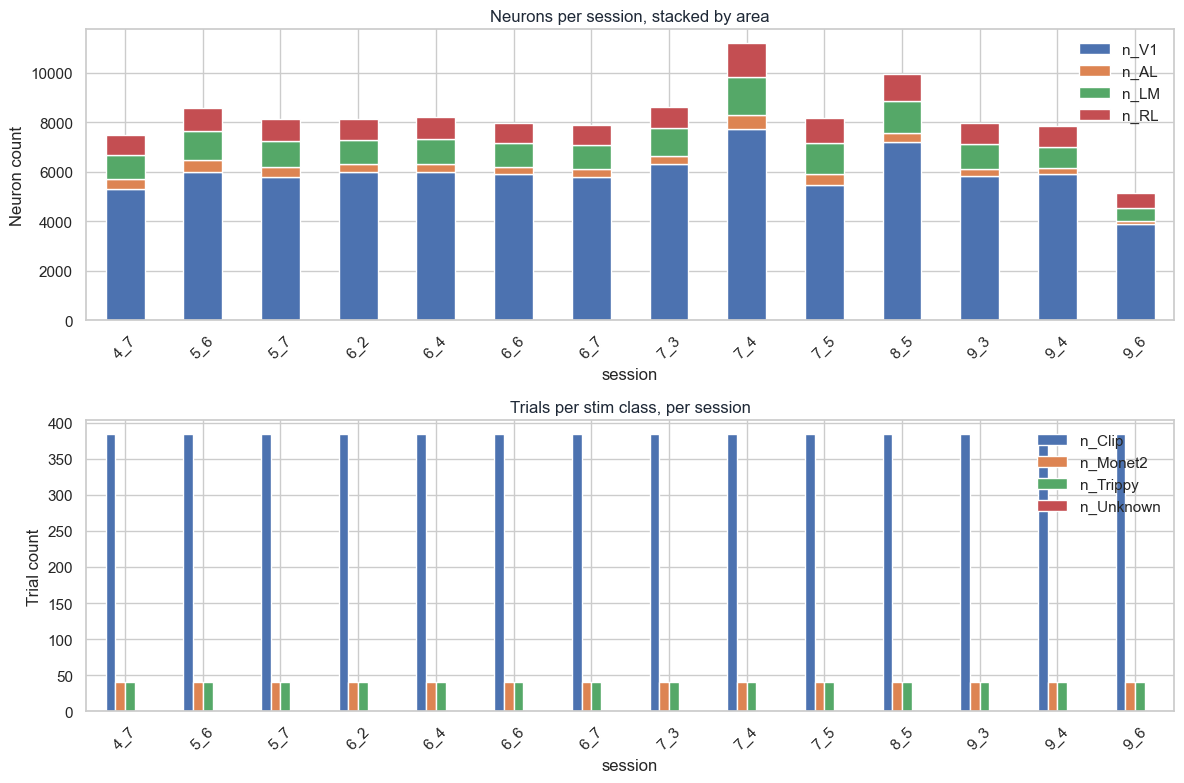

In [7]:
fig, _ = microns_eda.plot_cross_session_overview(summary_df)
fig.savefig(FIGURES_DIR / "1_2_neurons_and_stim_per_session.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
# Z-score for total neuron count (per-session). Uses ddof=0 (population
# std) to match flag_outlier_sessions, since the 14 sessions are the
# full population we care about, not a sample of a larger pool.
z_n_neurons = (summary_df["n_neurons"] - summary_df["n_neurons"].mean()) / summary_df["n_neurons"].std(ddof=0)

# Per-area percentages: what fraction of each session's neurons are in V1, AL, LM, RL.
area_pct = summary_df[["n_V1", "n_AL", "n_LM", "n_RL"]].div(summary_df["n_neurons"], axis=0) * 100

overview_1_2 = pd.DataFrame({
    "n_neurons": summary_df["n_neurons"],
    "z_n_neurons": z_n_neurons.round(2),
    "% V1": area_pct["n_V1"].round(1),
    "% AL": area_pct["n_AL"].round(1),
    "% LM": area_pct["n_LM"].round(1),
    "% RL": area_pct["n_RL"].round(1),
})
overview_1_2

,n_neurons,z_n_neurons,% V1,% AL,% LM,% RL
session,,,,,,
4_7,7493,-0.59,70.9,5.2,13.1,10.8
5_6,8592,0.28,70.0,5.4,13.5,11.1
5_7,8138,-0.08,71.0,5.0,13.1,11.0
6_2,8158,-0.07,73.6,3.9,12.0,10.6
6_4,8221,-0.02,73.0,3.9,12.5,10.7
6_6,7971,-0.21,74.1,3.6,12.3,10.0
6_7,7887,-0.28,73.6,3.9,12.2,10.3
7_3,8618,0.30,73.2,3.8,13.2,9.9
7_4,11201,2.33,69.0,5.1,13.7,12.2


**Interpretation:**

- **Two sessions are |z| > 2 outliers** in total neuron count (mean ≈ 8241, std ≈ 1270):
  - **9_6** (5130 neurons, z ≈ −2.45) (small field of view).
  - **7_4** (11201 neurons, z ≈ +2.33) (large field of view).
  - **8_5** (9941, z ≈ +1.34) is on the high side but within threshold.

- **Area mix is broadly stable.** V1 dominates (~70% in every session), with LM and RL roughly comparable (~10–14% each) and AL the smallest slice (~3–5%). The recording template (V1-centred with HVA peripheral coverage) is consistent across sessions.

- **9_6 also has the most skewed area composition:** AL drops to ~2.2% of the total (vs ~3–5% elsewhere) and V1 climbs to ~76%. So 9_6 is unusual on both axes, with fewer neurons *and* a less balanced area mix.

- **The trial-count plot confirms the table:** every session has the same 384 Clip / 40 Monet2 / 40 Trippy split, no Unknowns. Stimulus structure is identical across sessions.

**Implication:** for **per-session** analyses this is fine. For **pooled** analyses (e.g. concatenating neurons across sessions), 9_6 and 7_4 will weight the average asymmetrically, since 7_4 contributes ~2× more neurons than 9_6. If pooling, either subsample to a common count or weight by session. AL-specific analyses should treat 9_6 cautiously given how few AL neurons it contains (115).

### 1.3 Stimulus distribution

The second panel of the figure above shows trial counts by stim class per session.

**What we're spotting:** anomalously many "Unknown" trials in any one session, or skewed Clip/Monet2/Trippy ratios.

**What it means:** labeling issue or different experimental protocol.

**Interpretation:** Stimulus distribution is identical across all 14 sessions: 384 Clip + 40 Monet2 + 40 Trippy + 0 Unknown, so sessions are directly comparable on the stimulus axis.

### 1.4 Response magnitude distribution

**What we compute:** for each session, per-neuron mean response across all trials → one boxplot per session.

**What we're spotting:** a session whose box is shifted up/down or has unusual spread.

**What it means:** possible imaging-quality issue (calibration drift, photobleaching) that affects any analysis that compares absolute response levels.

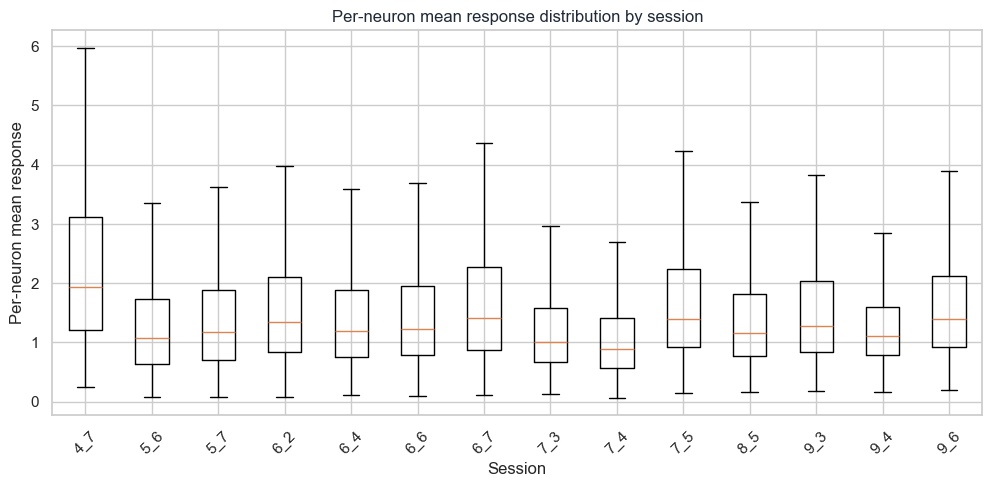

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))
microns_eda.plot_response_magnitude_by_session(reader, DATADIR, ax=ax)
fig.savefig(FIGURES_DIR / "1_4_response_magnitude_by_session.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation:**

- **Session 4_7 is clearly shifted up.** Median ≈ 1.95 vs ~1.0–1.4 elsewhere, with the box and whiskers stretched higher (upper whisker ~6 vs ~3–4 for the others). Confirms the flag from previous analysis in 1.1: session 4_7 has systematically larger per-neuron responses, not just a higher median.

- **Sessions 7_4 and 7_3 sit slightly low** (medians ~0.9 and ~1.0, narrower boxes), consistent with their lower variance values in 1.1.

- **The remaining 11 sessions overlap heavily**: medians ~1.05–1.4, similar IQRs and whisker ranges. No sign of calibration drift across the cohort as a whole.

**Implication:** absolute response levels are *not* directly comparable for 4_7. Any analysis using raw magnitudes (e.g. ranking neurons by activity, pooling across sessions) should either exclude 4_7 or z-score per session first. Per-session analyses are unaffected.

### 1.5 Behavioral state per session

**What we compute:** mean pupil diameter and mean treadmill speed, per session.

**What we're spotting:** unusually low pupil (drowsy mouse) or unusually high running (hyperactive).

**What it means:** a major confound for visual cortex. Neural activity may be dominated by behavior rather than vision in that session.

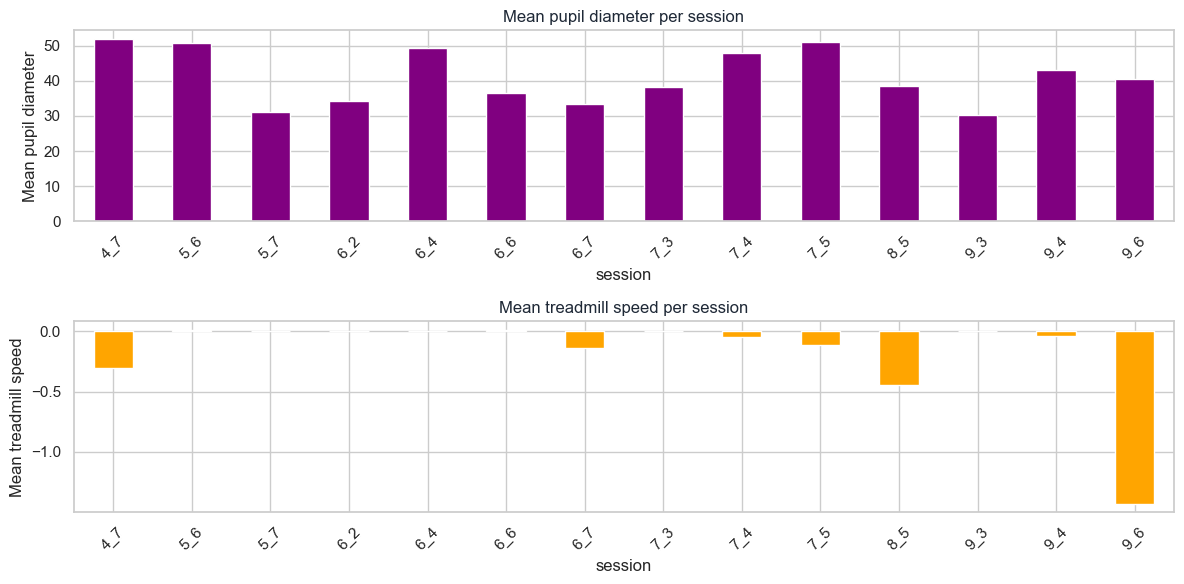

In [10]:
fig, _ = microns_eda.plot_behavior_by_session(summary_df)
fig.savefig(FIGURES_DIR / "1_5_behavior_by_session.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation:**

- **Pupil diameter** ranges from ~30 to ~52 across sessions. **9_3 (≈30) and 5_7 (≈31)** are the lowest (possibly drowsier mice, but not dramatically so, still ~60% of the highest). No session looks pathologically low.

- **Treadmill speed** is near zero for most sessions (|speed| < 0.15), confirming mostly stationary mice as expected for head-fixed passive viewing. Three sessions stand out by magnitude:
  - **9_6** (|speed| ≈ 1.43), by far the most active mouse, ~3× the next-highest. Already flagged in 1.1/1.2; this is the third independent reason to treat 9_6 cautiously.
  - **8_5** (|speed| ≈ 0.45) and **4_7** (|speed| ≈ 0.31). Moderately active, worth noting but not extreme.
  
- **No clear pupil/treadmill coupling** at the session level: 4_7 has both high pupil and moderate movement, but 9_6 (most active) has middling pupil. So behavioural state isn't moving as a single arousal axis here.

**Implication:** **9_6** is the main concern. High movement is a known confound for visual cortex, and running can drive V1 activity independently of the stimulus. For any analysis sensitive to behavioural state (decoding, tuning, noise correlations), either exclude 9_6 or include treadmill speed as a covariate. **8_5** and **4_7** are worth a second look but probably manageable. Low-pupil sessions (5_7, 9_3) are not extreme enough to flag on their own.

### 1.6 Outlier flag table

**What we compute:** z-scores per metric (1.2–1.5) plus a `warning` column listing which metrics each session fails (|z| > 2).

**What we're spotting:** a single place to see which sessions to treat with caution.

In [11]:
flagged = microns_eda.flag_outlier_sessions(summary_df)
microns_eda.plot_outlier_table(flagged)

,n_neurons,n_Unknown,z_n_neurons,z_median_per_neuron_mean,z_mean_pupil_diameter,z_mean_treadmill_speed,z_n_Unknown,warning,is_outlier
session,,,,,,,,,
4_7,7493,0,-0.588691,2.808945,1.417890,-0.345448,0.0,median_per_neuron_mean,True
5_6,8592,0,0.276409,-0.773544,1.268722,0.499965,0.0,,False
5_7,8138,0,-0.080966,-0.317941,-1.328860,0.497149,0.0,,False
6_2,8158,0,-0.065223,0.366682,-0.937328,0.482696,0.0,,False
6_4,8221,0,-0.015631,-0.282534,1.089689,0.492896,0.0,,False
6_6,7971,0,-0.212423,-0.113171,-0.634760,0.508047,0.0,,False
6_7,7887,0,-0.278546,0.631022,-1.045087,0.104722,0.0,,False
7_3,8618,0,0.296875,-1.045529,-0.392627,0.484080,0.0,,False
7_4,11201,0,2.330135,-1.541513,0.904797,0.353821,0.0,n_neurons,True


**Interpretation:**

Three sessions cross the |z|>2 threshold, each consistent with what we already saw upstream:

- **4_7**: `median_per_neuron_mean` (z ≈ +2.81). The high-activity outlier from 1.1 / 1.4. Box was visibly shifted up.
- **7_4**: `n_neurons` (z ≈ +2.33). Largest imaging volume (11,201 neurons). Activity and behaviour are normal.
- **9_6**: `n_neurons` (z ≈ −2.45) **and** `mean_treadmill_speed` (z ≈ −3.37). Smallest imaging volume *and* the most active mouse, flagged on two independent axes, the strongest case for caution.

The remaining 11 sessions, including **7_5**, carry no flags. **7_5** sits near the cohort centre on every axis (|z| ≤ 1.31 across all metrics, neuron count 8,194 vs cohort median 8,176) and looks like a representative session for the deep-dive, no override needed.

## Part 2: Deep-dive on session `7_5`

Now we move from cross-session statistics to studying one session in depth.

### 2a. Session structure

#### 2a.i Neuron coordinates in 3D

**What we compute:** 3D scatter of every neuron's pial position, colored by area.

**What we're spotting:** V1 forms a coherent spatial cluster, with higher areas (AL/LM/RL) at distinct positions. Outlier: scattered or sparse coverage → field-of-view problem.

In [12]:
deep_meta = microns_eda.get_session_meta(DATADIR, DEEP_DIVE_SESSION)

# Interactive 3D scatter via plotly: drag to rotate, scroll to zoom.
# (A static matplotlib version is also available via
#  microns_eda.plot_neuron_coords_3d if you need a saved figure.)
fig = microns_eda.plot_neuron_coords_3d_interactive(deep_meta)
fig.show()

**Interpretation:**

- **Tangentially the four areas form coherent clusters**: V1 is the large central block, AL/LM/RL surround it at distinct (x, z) locations. Matches expected mouse visual cortex anatomy.
- **The x-z plane shows the acquisition geometry clearly**: data is concentrated in 4 discrete tangential bands with empty space between them. It reflects the multi-field acquisition scheme used by the Baylor functional imaging team, which scans several spatially separated fields simultaneously rather than a continuous volume.
- **Each scan band crosses area boundaries**: V1 dominates the central portions, with AL/LM/RL appearing at the ends of the bands. So every band samples multiple areas, and cross-area comparisons within a session are well-supported.
- **Each band spans ~100–1000 µm in depth**, so all cortical layers are represented within each field. Layer-resolved analyses are viable.
- **No FOV defects**: AL is sparser than the others (matches its low share in the unit table), but coverage is uniform within each scan band.

Session `7_5` is anatomically clean for the deep-dive.

#### 2a.ii Trial timing strip

**What we compute:** one colored bar per trial, in trial order, colored by stim type.

**What we're spotting:** is the design *blocked* (long runs of one stim type) or *interleaved*?

**What it means:** blocked design correlates drift with stim class, a confound for any class-conditioned analysis.

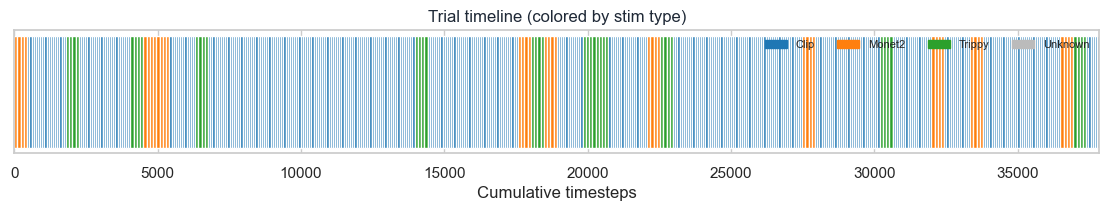

In [13]:
deep_responses, deep_boundaries, deep_stim_types = microns_eda.load_session_responses(
    reader, DATADIR, DEEP_DIVE_SESSION
)
deep_durations = np.diff(deep_boundaries)

fig, ax = plt.subplots(figsize=(14, 1.6))
microns_eda.plot_trial_timeline(deep_stim_types, trial_durations=deep_durations, ax=ax)
fig.savefig(FIGURES_DIR / "2a_ii_trial_timeline.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation:**

- **Design is interleaved, not blocked.** Monet2 (orange) and Trippy (green) trials appear scattered throughout the session rather than concentrated in dedicated blocks. Clip trials (blue) fill the rest.
- A few short clusters of Monet2 or Trippy trials are visible (e.g. around timesteps ~5000, ~18000, ~22000, ~32000), but these are short bursts on the order of a handful of trials rather than long blocks.
- Total session length spans ~37,000 timesteps (~82 min at 7.5 Hz), consistent with 464 trials of mixed durations.

**Implication:** stim class is decorrelated from time within the session, so any slow drift in neural activity (bleaching, arousal trends) will not systematically bias class-conditioned analyses. Safe to pool trials of the same class across the session.

#### 2a.iii Trial duration histogram

**What we compute:** histogram of trial lengths in timesteps.

**What we're spotting:** the expected bimodal distribution at 75 (Clip) and 113 (Monet2/Trippy) timesteps.

**What it means:** any time-domain analysis (PSTH, trajectories) must handle variable trial length.

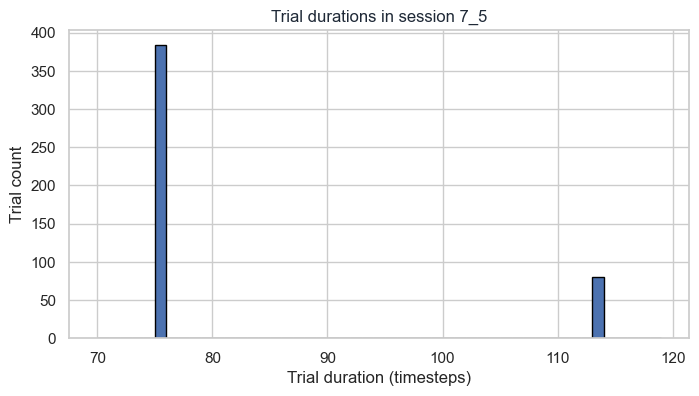

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(deep_durations, bins=np.arange(70, 120, 1), edgecolor="black")
ax.set_xlabel("Trial duration (timesteps)")
ax.set_ylabel("Trial count")
ax.set_title(f"Trial durations in session {DEEP_DIVE_SESSION}")
fig.savefig(FIGURES_DIR / "2a_iii_trial_durations.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation:**

- Bimodal distribution as expected: ~384 trials at 75 timesteps (Clip, ~10 s) and ~80 trials at 113 timesteps (Monet2 + Trippy, ~15 s). Counts match the stim breakdown from 1.1 (384 + 40 + 40 = 464).
- Each peak is a single tight bar, no jitter within a class, all trials of the same type have identical length.

**Implication:** time-aligned analyses (PSTH, trajectories, decoding over time) must either restrict to one stim class at a time or truncate to a common 75-timestep window. Cannot stack trials of mixed duration into a single matrix.

### 2b. Stimulus catalog

#### 2b.i Sample frames per stim class

**What we compute:** the middle frame of one example clip from each of `Clip`, `Monet2`, `Trippy`.

**What we're spotting:** intuition for what the mouse saw, and the visual difference between classes.

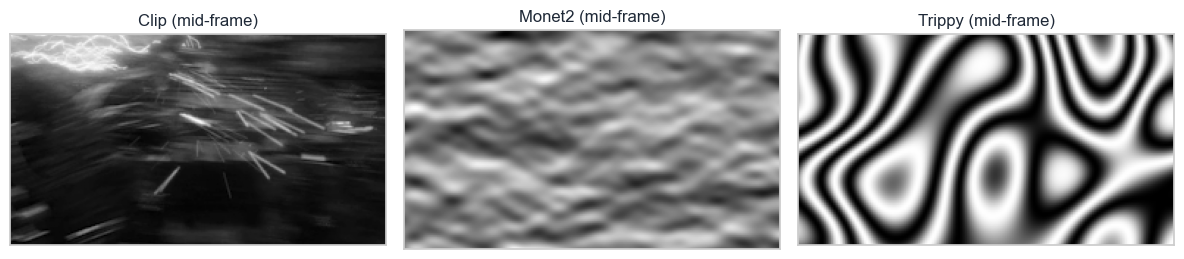

In [15]:
deep_stim_map = microns_eda.build_stim_type_map(reader, DEEP_DIVE_SESSION)
fig = microns_eda.plot_stim_examples(reader, deep_stim_map)
fig.savefig(FIGURES_DIR / "2b_i_stim_examples.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation:**

These are example frames showing what the mouse actually saw on the screen during each kind of trial. Each class has a different visual character:

- **Clip** is a collection of natural movie footage. The frame shown looks like a real-world scene captured by a camera (with motion blur from movement). These come from sources like cinematic films or sports videos.
- **Monet2** is a set of randomly generated textured patterns. Looks like noisy grayscale clouds. Built to have rich low-level visual structure (orientations, spatial frequencies) without any objects or meaning. Used to characterize how neurons respond to "raw" visual features.
- **Trippy** is a set of smooth, wavy synthetic patterns. Slowly deforming high-contrast curves, kind of like a lava lamp. Designed to drive visual neurons strongly and probe their tuning to spatial structure.

**Why this matters:** the three classes test very different things.
- Clips → how neurons respond to complex, natural input.
- Monet2 → controlled probing of low-level features (edges, textures).
- Trippy → strong, structured stimulation good for measuring tuning.

So when later in the analysis we compare neural responses across stim classes, we're really comparing how the brain handles "real world" vs "controlled noise" vs "structured synthetic" inputs.

#### 2b.ii Investigating "Unknown" trials

**What we compute:** for any "Unknown" hashes in this session, check whether they appear in `/types/` or `/videos/` of the H5 to recover their identity.

**What we're spotting:** whether Unknowns can be recovered, kept as a 4th class, or need to be dropped.

In [16]:
unknown_hashes = [h for h, t in deep_stim_map.items() if t == "Unknown"]
print(f"Total 'Unknown' hashes in session {DEEP_DIVE_SESSION}: {len(unknown_hashes)}")

with microns_eda.open_h5(DATADIR) as f:
    types_keys = set(f["types"].keys())
    video_keys = set(f["videos"].keys())
    for h in unknown_hashes[:5]:
        in_types = any(h in f["types"][k] for k in types_keys)
        in_videos = h in video_keys
        # Library may expose alternate encoding; cross-check.
        try:
            via_reader = reader.get_video_type(h)
        except Exception as e:
            via_reader = f"reader error: {e!s}"
        print(f"  hash={h!r}  in_types={in_types}  in_videos={in_videos}  reader_type={via_reader!r}")

Total 'Unknown' hashes in session 7_5: 0


**Interpretation:** Session `7_5` contains **0 Unknown trials**. Every hash in the session resolves to one of {Clip, Monet2, Trippy}. No recovery or special handling is needed for this deep-dive. The check is left in place so the diagnostic runs automatically if applied to another session or a future dataset version where Unknowns may appear.

### 2c. Neural responses

#### 2c.i Single-trial heatmaps per stim class

**What we compute:** one heatmap (neurons × time, neurons sorted by mean activity) per stim class, drawn for one example trial of each.

**What we're spotting:** sparse vs dense activity, time-locked structure, visible class differences at the heatmap level.

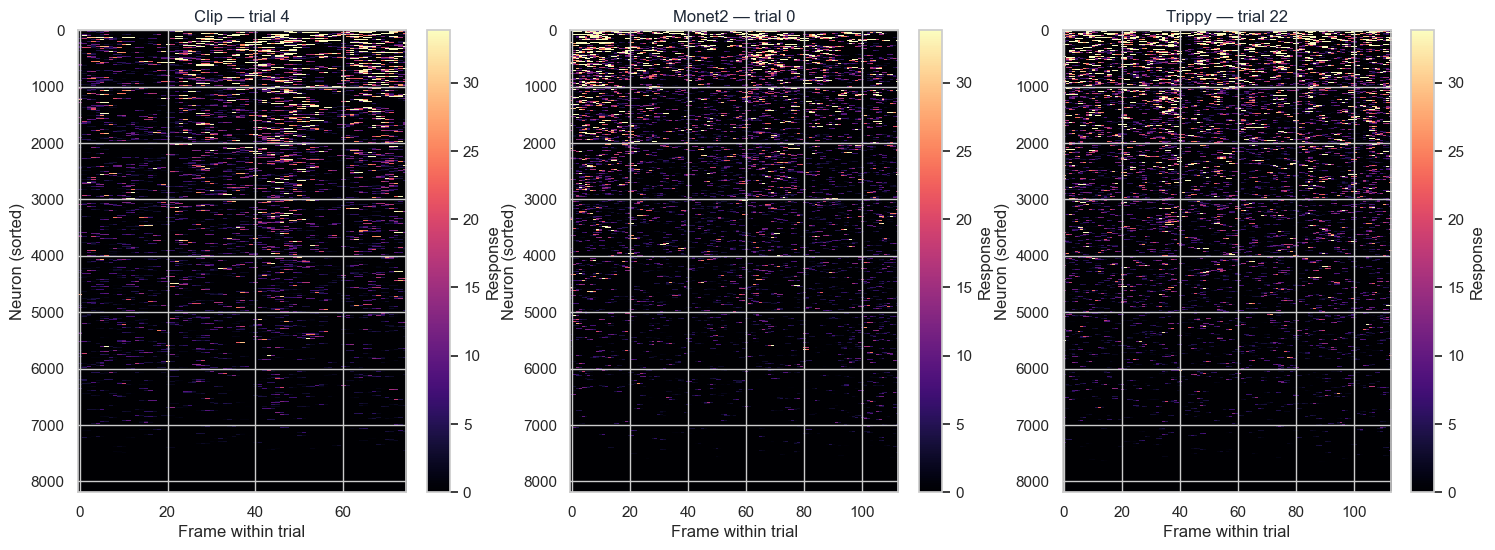

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, cls in zip(axes, ["Clip", "Monet2", "Trippy"]):
    candidates = np.where(deep_stim_types == cls)[0]
    if len(candidates) == 0:
        ax.set_title(f"{cls}: no trials")
        continue
    trial_idx = int(candidates[0])
    microns_eda.plot_response_heatmap(deep_responses, trial_idx, deep_boundaries, ax=ax)
    ax.set_title(f"{cls}: trial {trial_idx}")
fig.savefig(FIGURES_DIR / "2c_i_response_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation:**

- **Activity is sparse.** Even with the percentile-clipped color scale, most of the matrix is dark. At any given time, only a small fraction of the ~8,200 neurons are strongly active, consistent with the sparse coding picture of cortex.
- **Active neurons concentrate in the top portion** of each heatmap. This is expected: rows are sorted by mean activity, so the most-active neurons sit at the top by construction. The cell-by-cell texture in that band is real per-frame variability, not sorting.
- **No obvious time-locked stripes.** Activity looks fairly uniform along the time axis within each trial, with no sharp onset transient at frame 0 or sustained response shape that jumps out by eye. Any time-locked structure is too subtle to see at the single-trial level and will only emerge after trial averaging (the PSTH in 2c.ii).
- **No dramatic class differences at this level.** Clip, Monet2, and Trippy panels all look qualitatively similar: sparse activity in a top band, similar dynamic range (capped at ~30 in the shared scale). Differences between stim classes, if they exist, will need population-level or dimensionality-reduction methods to reveal.

**Takeaway:** single trials are too noisy to see stim-class structure directly. Averaging across trials (PSTH, next section) and dimensionality reduction will be needed to extract any class-conditional signal.

#### 2c.ii PSTH per stim class

**What is a PSTH?** A *Peri-Stimulus Time Histogram* is the average neural response over time, aligned to stimulus onset and averaged across many trials of the same class. Single trials are noisy, but averaging across repeats cancels out noise that isn't time-locked to the stimulus, leaving the typical response shape driven by the stimulus itself. "Per stim class" means we compute one such average for Clip, one for Monet2, one for Trippy, so we can compare them.

**What we compute:** for each stim class, the population-mean response (averaged over neurons) at each frame within a trial, then averaged across all trials of that class. One trace per class, time on the x-axis.

**What we're spotting:** clearly distinct trajectories (dim reduction will mostly confirm) vs overlapping trajectories (any structure must live in higher moments, first-moment analysis won't see it).

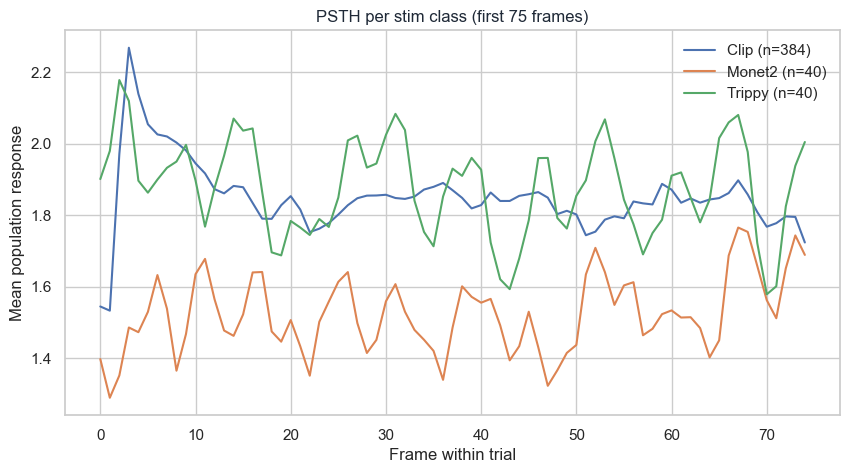

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))
microns_eda.plot_psth_by_stim(deep_responses, deep_boundaries, deep_stim_types, ax=ax)
fig.savefig(FIGURES_DIR / "2c_ii_psth_by_stim.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation:**

The three classes separate cleanly at the population-mean level:

- **Monet2 (orange) sits lowest** at ~1.4–1.7. The textured-noise stimulus drives the weakest average response.
- **Clip (blue) sits in the middle** at ~1.8–1.9, with a brief transient peak in the first few frames (~2.3 at frame 3) that decays into a roughly flat sustained level. The transient is the classic "stimulus onset" response. Neurons fire briefly when the image appears, then settle.
- **Trippy (green) sits highest** at ~1.9–2.1, fluctuating throughout the trial. The fluctuations likely track the smooth, slowly-changing wave patterns of the Trippy stimulus itself.

**Takeaway:** simply looking at the population mean is enough to tell the three stim classes apart, since they live at different baseline levels. This means class identity is encoded in the *first moment* (the average) of the population response, so even a coarse decoder should be able to distinguish them. We don't need to rely only on higher-order structure (covariance, geometry) to see class differences.

The Clip trace is also visibly smoother than the other two, which is partly because Clip has many more trials in the average (n=384 vs n=40), so the noise is reduced more. Worth keeping in mind when comparing trace "wiggliness" across classes. Some of that difference is sample-size, not signal.

#### 2c.iii Distribution of all response values

**What we compute:** histogram of the entire `responses` matrix, flattened.

**What we're spotting:** skew, scale, negative tail (calcium events vs deconvolved spikes). Informs the normalization choice in section 2e.

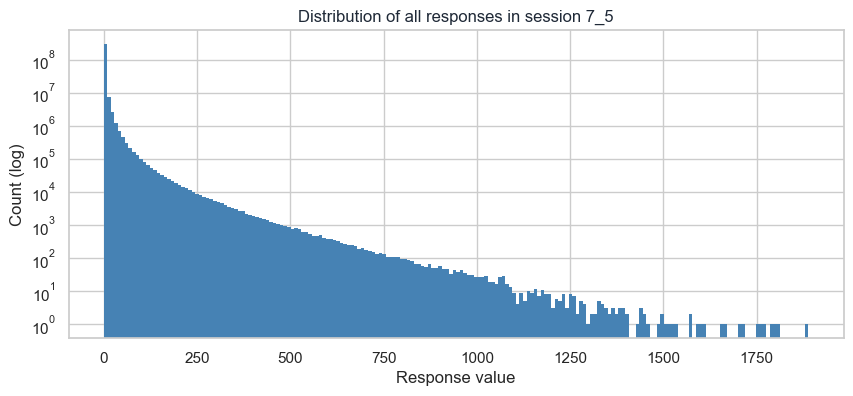

In [19]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(deep_responses.ravel(), bins=200, log=True, color="steelblue", edgecolor="none")
ax.set_xlabel("Response value")
ax.set_ylabel("Count (log)")
ax.set_title(f"Distribution of all responses in session {DEEP_DIVE_SESSION}")
fig.savefig(FIGURES_DIR / "2c_iii_response_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation:**
The histogram pools every value across all neurons, all frames, and all stim classes. Here we're looking at the global value distribution. To see class-conditional differences in the value distribution, we'd need a separate histogram per class overlaid (worth adding if relevant later).

- **Distribution shape:** strongly right-skewed, non-negative, unimodal. A massive concentration of values near zero (visible as the huge bar at ~0 reaching 10⁸ counts), and a long tail extending out to ~1800 that decays smoothly on the log-y axis. No negative values, no bimodality, no clipping at the top.

- **What this means:**
  - The signal is essentially mostly silent, occasionally large. Most neuron-frame combinations are inactive; activity is sparse and bursty.
  - A handful of extreme values dominate the scale. This is what heatmaps in 2c.i hihglights.
  - Mean and standard deviation are bad summary statistics here (the distribution is far from Gaussian). Medians, percentiles, and robust scales are more reliable.

**Implication for normalization (2e):** raw values shouldn't be fed directly into analyses that assume Gaussian-like data (PCA on raw values, plain z-scoring, anything mean/variance-based). Reasonable options are `log(1+x)` to compress the long tail, or per-neuron robust scaling (median + MAD) so each neuron contributes comparably regardless of its overall activity level.

### 2d. Behavior

#### 2d.i Single-trial alignment

**Why is this important?** When a video starts, two things could make neurons fire: the visual stimulus itself, or the mouse reacting to it (perking up, dilating pupils, moving on the treadmill). If behavior changes happen at the same moments as stimulus changes, the two signals get tangled and we can't tell which one is driving the neural activity. Stacking the neural heatmap on top of pupil and treadmill traces lets us eyeball whether behavioral spikes line up with stimulus onset. If they do, behavior is a confound we'll need to control for; if they don't, the response is more cleanly tied to vision.

**What we compute:** the response heatmap of one example trial with pupil-diameter and treadmill-speed traces stacked beneath, all sharing the time axis.

**What we're spotting:** behavior changes that are synchronized with stimulus onset (the mouse perks up when the screen lights up).

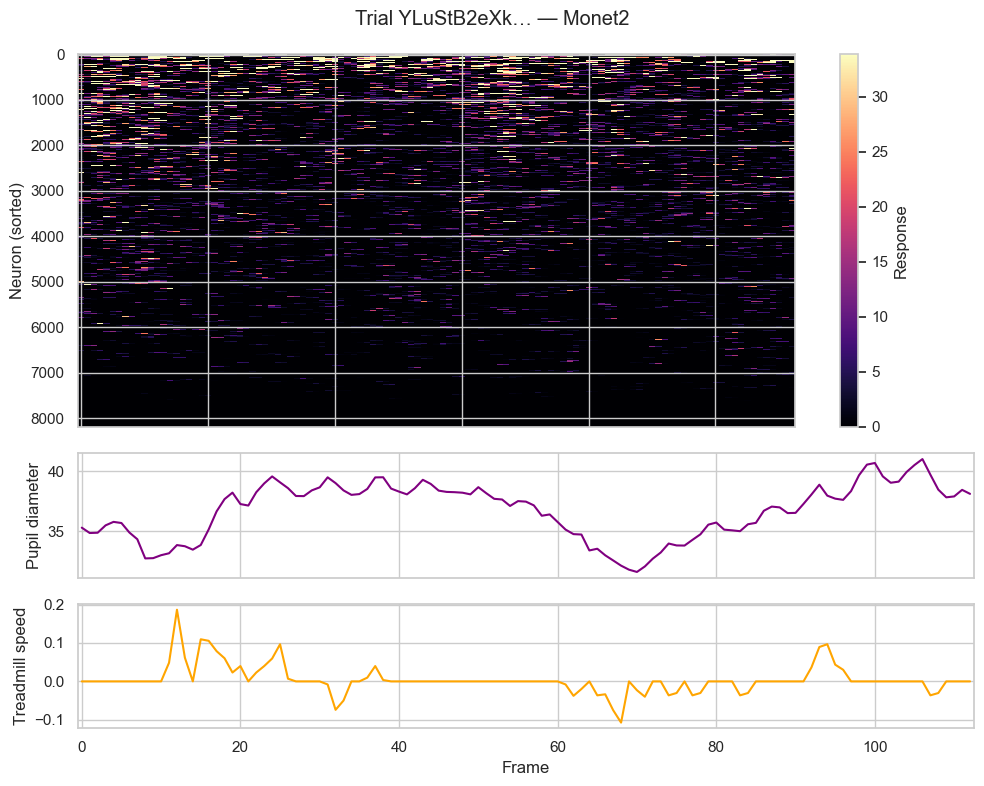

In [20]:
example_trial = microns_eda.load_trial(reader, DATADIR, DEEP_DIVE_SESSION, 0)

# Use the same percentile cap as 2c.i so the heatmap reveals structure
# instead of compressing into near-black.
example_vmax = float(np.percentile(deep_responses, 99))
fig, _ = microns_eda.plot_behavior_traces(example_trial, vmin=0, vmax=example_vmax)
fig.savefig(FIGURES_DIR / "2d_i_behavior_alignment.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation:**

- **Heatmap:** The activity in the top band is visible: a few hundred neurons fire at varying times throughout the trial, while the bulk of the population (rows below ~3000) is mostly silent.
- **No clear stimulus-onset transient.** Activity is spread across the trial rather than concentrated at frame 0. Single trials are noisy by nature.
- **Behavior traces stay calm.** Pupil drifts gently between ~33 and ~41, no sharp dilation at frame 0. Treadmill is near zero (small twitches at frames ~12, ~25, ~67, all |speed| < 0.2). The mouse is not reacting behaviorally to the stimulus.
- **No visible alignment between behavior and neural activity.** The brief treadmill bumps and pupil dips don't coincide with obvious bursts of population activity in the heatmap. For this trial, behavior is not the dominant driver of the neural signal.

**Caveat:** this is one trial of one stim class. The cross-trial averaged check (next cell) is what tells us whether the picture holds in general.

#### 2d.ii Behavior by stim class

**What we compute:** boxplots of mean pupil diameter and mean treadmill speed per stim class.

**What we're spotting:** systematic differences (e.g. "Monet2 trials always coincide with running"). If present, separability of those classes in neural space could be behavior-driven, not visual.

Pupil per-trial means: 464/464 finite, range [14.80, 85.63]
Treadmill per-trial means: 464/464 finite, range [-7.4450, 0.2607]


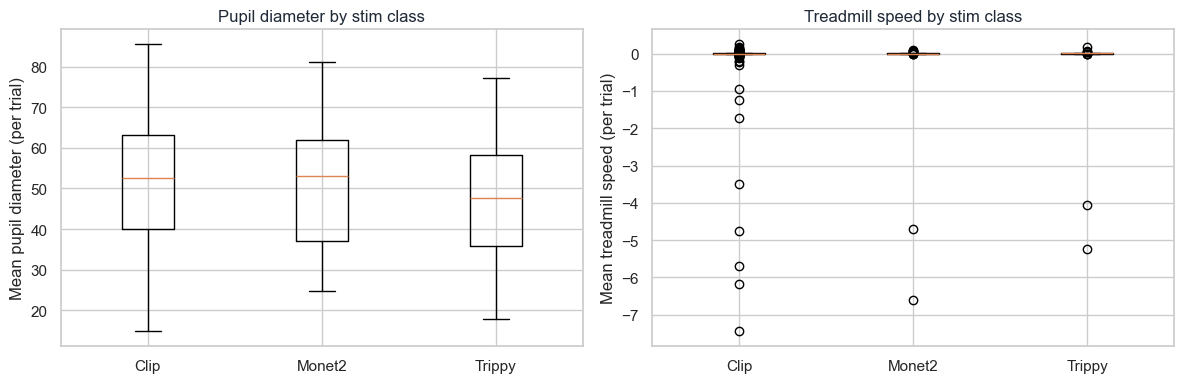

In [21]:
# Collect per-trial behavior arrays for the deep-dive session.
deep_pupil_per_trial = []
deep_tread_per_trial = []
with microns_eda.open_h5(DATADIR) as f:
    trials_grp = f["sessions"][DEEP_DIVE_SESSION]["trials"]
    for i in range(len(deep_stim_types)):
        deep_pupil_per_trial.append(trials_grp[str(i)]["pupil"][...])
        deep_tread_per_trial.append(trials_grp[str(i)]["treadmill"][...])

# nan-aware per-trial means: pupil/treadmill arrays contain NaN frames
# (sensor dropouts). Plain .mean() would propagate NaN to most trials.
per_trial_pupil_means = np.array([np.nanmean(p[2]) for p in deep_pupil_per_trial])
per_trial_tread_means = np.array([np.nanmean(t) for t in deep_tread_per_trial])

print(f"Pupil per-trial means: {np.isfinite(per_trial_pupil_means).sum()}/{len(per_trial_pupil_means)} finite, "
      f"range [{np.nanmin(per_trial_pupil_means):.2f}, {np.nanmax(per_trial_pupil_means):.2f}]")
print(f"Treadmill per-trial means: {np.isfinite(per_trial_tread_means).sum()}/{len(per_trial_tread_means)} finite, "
      f"range [{np.nanmin(per_trial_tread_means):.4f}, {np.nanmax(per_trial_tread_means):.4f}]")

fig, (ax_p, ax_t) = plt.subplots(1, 2, figsize=(12, 4))
classes = ["Clip", "Monet2", "Trippy"]

# Drop NaN per group before passing to boxplot (it can't summarize all-NaN groups).
def _per_class(arr, cls):
    vals = arr[deep_stim_types == cls]
    return vals[np.isfinite(vals)]

ax_p.boxplot([_per_class(per_trial_pupil_means, c) for c in classes], tick_labels=classes)
ax_p.set_ylabel("Mean pupil diameter (per trial)")
ax_p.set_title("Pupil diameter by stim class")
ax_t.boxplot([_per_class(per_trial_tread_means, c) for c in classes], tick_labels=classes)
ax_t.set_ylabel("Mean treadmill speed (per trial)")
ax_t.set_title("Treadmill speed by stim class")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "2d_ii_behavior_by_stim.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation:**

- **Pupil:** distributions are nearly identical across the three stim classes. Medians sit around 48–53, IQRs and whisker ranges overlap heavily (~15–85 for all three). No systematic difference in arousal between classes. Trippy is very slightly lower (median ~48 vs ~52–53), but well within the spread.
- **Treadmill:** the bulk of trials cluster near zero in all three classes (calm, stationary mouse). A handful of outlier trials with strongly negative speeds appear in each class. Clip has the most extreme outlier (~−7.4), but Monet2 and Trippy also have outliers in the same range. No class is systematically associated with running.
- **No class–behavior coupling.** The three stim classes are interleaved across behavioral states rather than concentrated in a particular state. Good news for downstream analyses.

**Implication:** if Clip / Monet2 / Trippy turn out to be separable in the neural data, that separation cannot be explained by "the mouse was always running for class X" or "pupil was always larger for class Y". The behavioral conditions are matched. Class differences in neural space can be attributed to the visual stimulus rather than to behavioral confounds.

#### 2d.iii Behavior–response correlation

**What we compute:** Pearson r across trials between (per-trial mean population response) and (per-trial mean pupil), and similarly for treadmill.

**What we're spotting:** |r| > 0.3 means behavior must be regressed out before dim reduction.

**What is Pearson r?** A correlation coefficient measuring the *linear* relationship between two variables, ranging from −1 to +1.
- **r = +1**: perfectly linear positive relationship (one variable goes up, the other always goes up).
- **r = 0**: no linear relationship.
- **r = −1**: perfectly linear negative relationship.
- **|r| > 0.3** is the threshold we use here as a rule of thumb: above it, the behavioral variable explains enough variance in the neural response that we can't ignore it.

We note that Pearson only captures *linear* relationships. A strong nonlinear coupling could exist with low r.

r(response, pupil)     = +0.183
r(response, treadmill) = -0.387


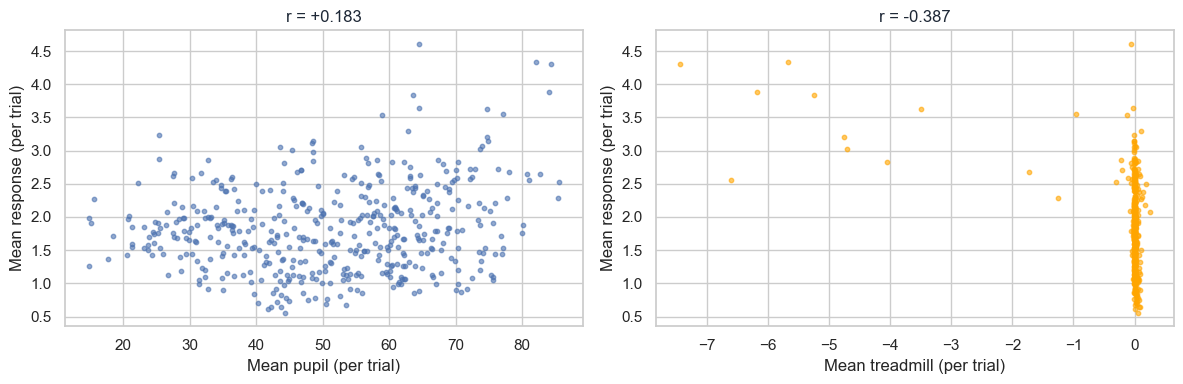

In [22]:
beh_align = microns_eda.compute_behavior_alignment(
    deep_responses, deep_boundaries, deep_pupil_per_trial, deep_tread_per_trial
)
print(f"r(response, pupil)     = {beh_align.attrs['corr_response_pupil']:+.3f}")
print(f"r(response, treadmill) = {beh_align.attrs['corr_response_treadmill']:+.3f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.scatter(beh_align["mean_pupil"], beh_align["mean_response"], s=10, alpha=0.6)
ax1.set_xlabel("Mean pupil (per trial)")
ax1.set_ylabel("Mean response (per trial)")
ax1.set_title(f"r = {beh_align.attrs['corr_response_pupil']:+.3f}")

ax2.scatter(beh_align["mean_treadmill"], beh_align["mean_response"], s=10, alpha=0.6, color="orange")
ax2.set_xlabel("Mean treadmill (per trial)")
ax2.set_ylabel("Mean response (per trial)")
ax2.set_title(f"r = {beh_align.attrs['corr_response_treadmill']:+.3f}")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "2d_iii_behavior_response_corr.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation:**

- **Pupil ↔ response:** r = +0.183. Below the 0.3 threshold. There's a weak positive trend (more dilated pupil → slightly higher mean activity), but it's noisy and explains only ~3% of the variance (r² ≈ 0.03). Not strong enough to require regressing out.
- **Treadmill ↔ response:** r = −0.387. **Above threshold.** The scatter shows the structure clearly: most trials cluster near treadmill speed = 0 with a wide spread of responses, but the handful of trials with strongly negative treadmill speeds (running outliers) all show *high* mean responses (2.5–4.5). These ~10–15 outlier trials are doing most of the correlation work.
- **Caveat:** the treadmill correlation is driven by a small number of extreme trials, not a smooth relationship across the bulk of the data. Removing those outliers would likely drop r below 0.3.

**Implication:** treadmill crosses the 0.3 threshold, so it's worth controlling for before dimensionality reduction. Two reasonable options:
1. **Drop the running-outlier trials** (e.g. trials with |mean treadmill| > some cutoff). Simple and clean given the bulk of trials are stationary anyway.
2. **Regress treadmill out of the response matrix** before PCA/UMAP. It keeps all trials but removes the linear contribution of running.

Pupil is below threshold and can be left alone.

### 2d.iv Running-outlier removal (treadmill confound)

The 2d.iii scatter showed `r(response, treadmill) = -0.387`, above our 0.3 confound threshold. But the relationship is *not* smooth:

- ~450 calm trials cluster at treadmill ≈ 0 with no clear coupling between treadmill and response.
- ~10–15 outlier trials sit at treadmill in [−7, −1], all with high mean responses, and they alone drive the correlation.

Regressing treadmill out would impose a linear correction on every trial. Since the bulk don't follow that linear pattern, the cleaner intervention is to **drop** the outlier trials.

**Threshold:** `|treadmill| > 1.0`. Round number matching the visible gap between the two regimes. Defensible anywhere in [0.5, 1.0]; if 1.0 leaves the post-cleaning correlation above 0.3, lower it and re-run.

The cell below builds `keep_mask` and `clean_trial_indices`: downstream analyses (Part 2e and the dim-reduction phase) subset trials with these.

In [23]:
# Drop running-outlier trials before any trial-conditioned downstream analysis.
TREADMILL_OUTLIER_THRESHOLD = 1.0

clean_trial_indices, running_mask = microns_eda.compute_clean_trial_indices(
    per_trial_tread_means,
    threshold=TREADMILL_OUTLIER_THRESHOLD,
)
keep_mask = ~running_mask

n_dropped = int(running_mask.sum())
n_total = len(per_trial_tread_means)
n_kept = int(keep_mask.sum())
print(f"Threshold: |treadmill| > {TREADMILL_OUTLIER_THRESHOLD}")
print(f"Dropped {n_dropped}/{n_total} trials ({100 * n_dropped / n_total:.1f}%); kept {n_kept}.")

# Stim-class breakdown of dropped vs kept: sanity check that we're not biasing one class.
print("\nDropped trials by stim class:")
print(pd.Series(deep_stim_types[running_mask]).value_counts().to_string())
print("\nKept trials by stim class:")
print(pd.Series(deep_stim_types[keep_mask]).value_counts().to_string())

# Recompute behavior-response correlations on the cleaned subset, reusing
# beh_align (already computed in 2d.iii).
clean = beh_align.iloc[clean_trial_indices]
clean_corr_pupil = float(clean["mean_response"].corr(clean["mean_pupil"]))
clean_corr_tread = float(clean["mean_response"].corr(clean["mean_treadmill"]))
print(f"\nAfter cleaning (n={n_kept}):")
print(f"  r(response, pupil)     = {clean_corr_pupil:+.3f}  (threshold: |r| > 0.3)")
print(f"  r(response, treadmill) = {clean_corr_tread:+.3f}  (threshold: |r| > 0.3)")

if abs(clean_corr_tread) > 0.3:
    print(f"\n>>> Treadmill correlation still above 0.3. "
          f"Lower TREADMILL_OUTLIER_THRESHOLD (try 0.5) and re-run this cell.")
else:
    print(f"\nTreadmill confound resolved. Use clean_trial_indices "
          f"({len(clean_trial_indices)} trials) to subset trials downstream.")

Threshold: |treadmill| > 1.0
Dropped 11/464 trials (2.4%); kept 453.

Dropped trials by stim class:
Clip      7
Trippy    2
Monet2    2

Kept trials by stim class:
Clip      377
Monet2     38
Trippy     38

After cleaning (n=453):
  r(response, pupil)     = +0.100  (threshold: |r| > 0.3)
  r(response, treadmill) = -0.224  (threshold: |r| > 0.3)

Treadmill confound resolved. Use clean_trial_indices (453 trials) to subset trials downstream.


**Interpretation:**

- **Dropped only 11 trials out of 464 (~2.4%).** We lose almost no data.
- **The dropped trials are spread across all three stim classes** roughly proportionally (7 Clip, 2 Monet2, 2 Trippy). Each class loses a small chunk, so we're not biasing one class over another.
- **Both behavioral correlations are now below the 0.3 threshold:**
  - Treadmill: −0.387 → **−0.224** (cleared the threshold).
  - Pupil: +0.183 → **+0.100** (was already fine, dropped further as a side effect).
- **Per-class trial counts are still healthy:** 377 Clip + 38 Monet2 + 38 Trippy. Plenty of trials to support trial-averaged analyses for each class.

**Bottom line:** Removing 11 noisy trials lets us interpret any future class differences in the neural data as being about what the mouse saw, not what the mouse was doing. Keep `clean_trial_indices`.

### 2e. Preprocessing diagnostics

#### 2e.0 Verify the pupil-diameter channel

`summarize_session` and `compute_behavior_alignment` assume pupil channel index 2 is the diameter. The H5 inspection labels four channels as (center_x, center_y, diameter, ?). Verify empirically: the diameter channel should be strictly positive (a length), with smaller variance relative to mean than the position channels.

**What we're spotting:** if the assumption is wrong, the behavior section's correlations are meaningless and we need to fix it.

In [24]:
# Heuristic: the pupil-diameter channel is the strictly-positive channel
# with the largest relative variability (std/mean). Position channels in
# a head-fixed mouse barely move (std/mean ~0.2%); the unknown 4th channel
# is suspiciously stable (~3.7%); a real diameter signal dilates and
# constricts so it has CoV ~6%+. Threshold: std/mean > 0.05.
COV_THRESHOLD = 0.05

ch_means = example_trial["pupil"].mean(axis=1)
ch_stds = example_trial["pupil"].std(axis=1)
ch_min = example_trial["pupil"].min(axis=1)
ch_cov = ch_stds / np.where(np.abs(ch_means) > 1e-9, np.abs(ch_means), 1.0)

print("channel | min     | mean    | std     | std/mean | candidate")
for i in range(4):
    is_candidate = (ch_min[i] > 0) and (ch_cov[i] > COV_THRESHOLD)
    label = "diameter?" if is_candidate else ""
    print(f"   {i}    | {ch_min[i]:+.3f} | {ch_means[i]:+.3f} | {ch_stds[i]:+.3f} | {ch_cov[i]:.4f}  | {label}")

# Verify the heuristic produces a single candidate, and check it matches
# the PUPIL_DIAMETER_CHANNEL assumption hard-coded in microns_eda.
detected = [i for i in range(4) if ch_min[i] > 0 and ch_cov[i] > COV_THRESHOLD]
PUPIL_DIAMETER_CHANNEL_ASSUMED = 2
if len(detected) == 1:
    diameter_channel = detected[0]
    if diameter_channel == PUPIL_DIAMETER_CHANNEL_ASSUMED:
        print(f"\nDetected diameter channel: {diameter_channel}: matches "
              f"PUPIL_DIAMETER_CHANNEL = {PUPIL_DIAMETER_CHANNEL_ASSUMED} used by "
              f"summarize_session / plot_behavior_traces / compute_behavior_alignment.")
    else:
        print(f"\n>>> MISMATCH: heuristic detected channel {diameter_channel} "
              f"but module uses {PUPIL_DIAMETER_CHANNEL_ASSUMED}. Update the "
              f"PUPIL_DIAMETER_CHANNEL default in summarize_session, "
              f"plot_behavior_traces, and compute_behavior_alignment, then "
              f"re-run the behavior cells.")
else:
    print(f"\nWARNING: heuristic returned {len(detected)} candidates: {detected}. "
          f"Inspect channels manually before relying on PUPIL_DIAMETER_CHANNEL.")

channel | min     | mean    | std     | std/mean | candidate
   0    | +1072.782 | +1076.538 | +2.031 | 0.0019  | 
   1    | +598.051 | +601.489 | +1.505 | 0.0025  | 
   2    | +31.611 | +36.734 | +2.313 | 0.0630  | diameter?
   3    | +24.231 | +26.502 | +0.979 | 0.0369  | 

Detected diameter channel: 2 — matches PUPIL_DIAMETER_CHANNEL = 2 used by summarize_session / plot_behavior_traces / compute_behavior_alignment.


#### 2e.i Mean vs variance: log-log

**What we compute:** scatter of per-neuron mean against per-neuron variance, with histograms of mean / variance / sparsity.

**What we're spotting:** slope ≈ 1 → Poisson-like (suggest sqrt VST); slope ≈ 2 → multiplicative noise (suggest z-score).

Silent neurons: 0 / 8194


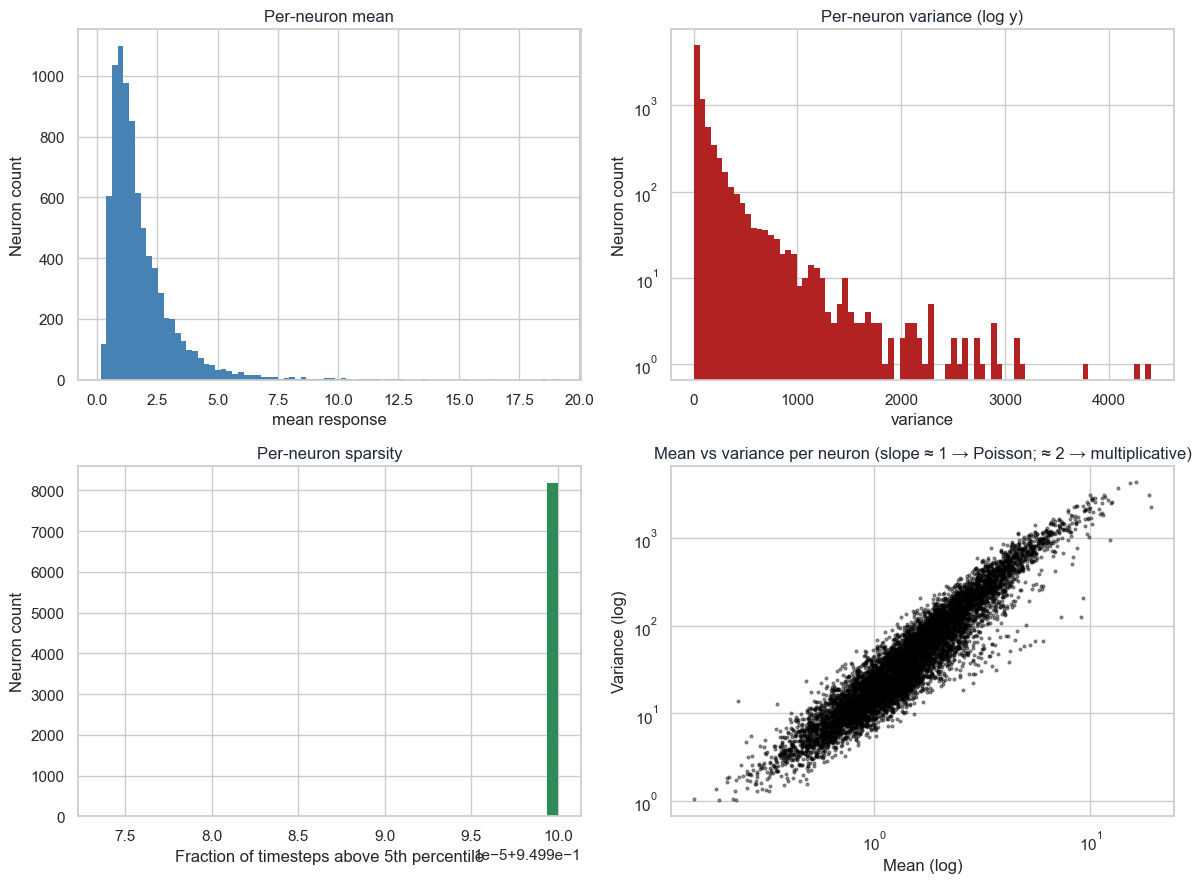

In [25]:
neuron_stats = microns_eda.compute_neuron_stats(deep_responses)
print(f"Silent neurons: {int(neuron_stats['is_silent'].sum())} / {len(neuron_stats)}")

fig, _ = microns_eda.plot_neuron_stat_distributions(neuron_stats)
fig.savefig(FIGURES_DIR / "2e_i_neuron_stat_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation:**

- Per-neuron mean: most neurons fire at low rates (~1–3), with a few highly active ones extending to ~20. Sparse population.
- Per-neuron variance: drops by orders of magnitude across neurons; high-variance neurons coincide with high-mean neurons.
- Per-neuron sparsity: all neurons hover at the same fraction of "above-5th-percentile" timesteps (~0.95). Tells us little, likely a property of the data definition, not biology.
- **Mean vs variance (log-log):** clear linear band with slope ≈ 2. Variance grows roughly with the *square* of the mean. This is multiplicative-noise scaling, not Poisson.

**Implication for normalization (next cell):** slope ≈ 2 favors **per-neuron z-scoring** or **log(1+x)** rather than a square-root variance-stabilizing transform. Consistent with the heavy-tailed global distribution observed in 2c.iii.

#### 2e.ii Sparsity histogram

The third panel above is the sparsity histogram. **What we're spotting:** bimodality or a silent tail → sets the Quality Control (QC) threshold for excluding silent neurons.

The sparsity histogram is not informative as drawn. Using each neuron's own 5th percentile as the activity cutoff forces every neuron to sit at fraction ≈ 0.95 by construction. No QC threshold can be read from this panel.

If silent-neuron QC turns out to matter for downstream analyses, a more useful sparsity metric would be the fraction of timesteps with response > 0 (or above a fixed global threshold), which would actually reveal silent vs active neurons. For now, given that the per-neuron mean histogram (top-left) already shows no neurons stuck at zero, no obvious QC dropout step is needed.

#### 2e.iii Neuron × neuron correlation

**What we compute:** correlation matrix on a `CORRELATION_SUBSAMPLE_N`-neuron random subsample, sorted by area.

**What we're spotting:** block structure within V1 (expected); cross-area separation; or very high off-diagonal mass → multicollinearity → motivates whitening.

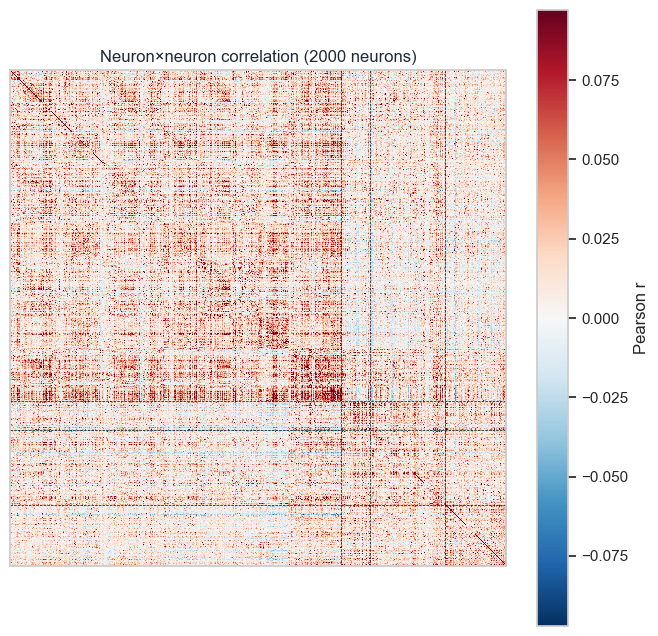

In [26]:
corr, sampled = microns_eda.compute_correlation_matrix(
    deep_responses, n_subsample=CORRELATION_SUBSAMPLE_N, seed=RANDOM_SEED
)
brain_areas_decoded = np.array([
    a.decode("utf-8", "replace") if isinstance(a, bytes) else str(a)
    for a in deep_meta["brain_areas"]
])
area_per_sampled = brain_areas_decoded[sampled]

fig, ax = plt.subplots(figsize=(8, 8))
microns_eda.plot_correlation_heatmap(corr, area_per_neuron=area_per_sampled, ax=ax)
fig.savefig(FIGURES_DIR / "2e_iii_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation:**

- **Off-diagonal correlations are very small.** The colorbar maxes out at ±0.09, so even the strongest pairs are only weakly correlated. Most of the matrix sits near zero (white). Neurons are largely independent of each other.
- **Faint block structure is visible.** Areas were sorted along the diagonal, so any "boxes" along the diagonal would mean neurons within an area are more correlated with each other than with neurons in other areas. There's a hint of this: slightly redder regions in the upper-left area (likely V1, the largest block), but the effect is subtle.
- **Vertical/horizontal stripes** appear at certain neuron indices (visible as redder columns/rows around the middle and right). These are individual neurons whose activity correlates broadly with many others, possibly highly active "hub" neurons or units picking up shared session-wide signals (e.g. arousal). They're not a problem, just worth noting.
- **No large block of high correlation.** If many neurons were duplicating each other's activity (multicollinearity), we'd see big red squares; we don't.

**Implication:** correlations are low overall and there's no strong multicollinearity, so a whitening step before dimensionality reduction is not strictly necessary. PCA on the (z-scored) data should behave well: components won't be dominated by a small group of redundant neurons.

#### 2e.iv Drift over trials

**What we compute:** mean population activity per trial vs. trial index, plus a linear fit.

**What we're spotting:** monotonic decrease (photobleaching) or sudden jumps (recording artifact). Motivates detrending or per-trial normalization.

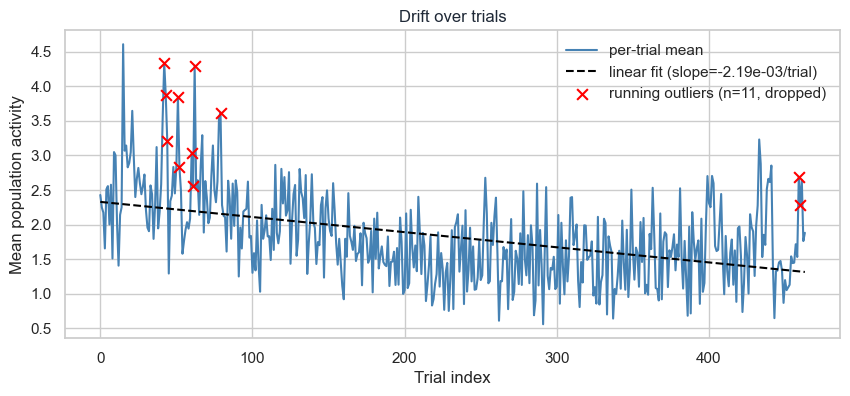

In [27]:
drift_df = microns_eda.compute_drift(deep_responses, deep_boundaries)
fig, ax = plt.subplots(figsize=(10, 4))
microns_eda.plot_drift(drift_df, ax=ax)

# Highlight running-outlier trials so we can see where they sit in the session.
dropped_indices = np.where(running_mask)[0]
if len(dropped_indices) > 0:
    ax.scatter(
        dropped_indices,
        drift_df.loc[dropped_indices, "mean_activity"],
        marker="x", s=60, color="red", zorder=5,
        label=f"running outliers (n={len(dropped_indices)}, dropped)",
    )
    ax.legend()

fig.savefig(FIGURES_DIR / "2e_iv_drift.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation:**

- **Slope:** −2.19 × 10⁻³ per trial → over 464 trials, the linear fit drops by ~1.0 unit. Going from a starting value of ~2.3 down to ~1.3, that's about a **45% decrease** in mean activity from start to end of the session.
- **Pattern is consistent with photobleaching** (gradual fluorescence loss as the indicator gets exposed to laser light over time): smooth, monotonic, no sudden jumps or step changes. Trial-to-trial noise around the fit is large (single-trial means swing between ~0.5 and ~4.5), so the drift is a slow underlying trend, not a dominant signal.
- **Running outliers** flagged in 2d.iv (red ×) sit above the trend, mostly in the first ~80 trials. Confirms the drop step was reasonable: those trials are not just running, they're running *and* high-activity.

**Combining the diagnostics from 2e:**

- **Mean-vs-variance slope (2e.i) ≈ 2** → multiplicative noise → favors **per-neuron z-scoring** or **log(1+x)** over a sqrt-VST.
- **Drift ~45% across the session (this cell)** → significant. Per-neuron z-scoring computed over the whole session would underestimate the std for early trials and overestimate it for late ones, leaving residual drift in the normalized data. **Detrending first, then z-scoring** is the safer recipe. Alternatively, per-trial normalization (e.g. dividing each trial by its baseline) can absorb the drift implicitly.
- **Silent neurons (2e.ii)** → no QC threshold needed. The per-neuron mean histogram (2e.i, top-left) showed no spike at zero; no neurons are dead.

**Chosen preprocessing pipeline for downstream analyses:**
1. Subset to `clean_trial_indices` (drop running outliers, from 2d.iv).
2. Detrend the per-trial mean across the session (subtract the linear fit, or fit a smooth baseline).
3. Per-neuron z-score, or `log(1+x)` then z-score, to handle the multiplicative noise structure.
4. PCA / dim reduction can proceed without explicit whitening (correlations were low in 2e.iii).

## Part 3: Takeaways

### 3.1 Dataset structure
*Synthesize from Part 1: how many sessions are usable, trial composition, what `Unknown` trials turned out to be (resolved by `MicronsFunctionalReader` URL-encoding handling, 0 Unknown across the 14 sessions), whether `7_5` remains the right deep-dive, and any sessions to exclude from the per-session pipeline.*

### 3.2 Chosen preprocessing for the dim-reduction phase
- **Normalization:** *Choose between z-score / sqrt VST / none. Drive the choice from the mean-vs-variance log-log slope (2e.i) and the response distribution shape (2c.iii).*
- **Neuron QC:** *Drop silent neurons (variance = 0). Set the sparsity threshold from 2e.ii. Final neuron count: …*
- **Behavior:** *In session `7_5`, treadmill r dropped from −0.387 to −0.224 after removing 11 running-outlier trials (|treadmill| > 1.0); pupil r is below threshold throughout. Apply the same outlier-removal step in any session whose raw |r| exceeds 0.3.*
- **Drift:** *Slope from 2e.iv. Detrend if the linear trend is significant relative to per-trial variability.*

### 3.3 Watchouts for the dim-reduction phase
- **Sessions to exclude:** *List sessions flagged in 1.6 with reasons.*
- **Variable trial duration (75 vs 113 frames):** any time-domain analysis must truncate or pad explicitly. Don't silently average mismatched lengths.
- **Behavior confounds:** the running-outlier-removal step is per-session, re-run `2d.iv` on each new session before pooling.
- **Trial subsetting:** downstream analyses (PCA per stim class, UMAP, CEBRA) should subset trials with `clean_trial_indices` to keep the running confound out.

### 3.4 Reusable per-session pipeline
The functions in `microns_eda.py` are written so swapping `DEEP_DIVE_SESSION` and re-running Part 2 reproduces every diagnostic for any session. The diagnostic table for one session is the input to the dim-reduction pipeline:

| Step | Function(s) used | Output |
|---|---|---|
| Load session | `load_session_responses`, `get_session_meta`, `build_stim_type_map` | `responses`, `trial_boundaries`, `stim_types_per_trial` |
| Behavior cleanup | `compute_behavior_alignment` + threshold | `keep_mask`, `clean_trial_indices` |
| Per-neuron QC | `compute_neuron_stats` + sparsity threshold | neuron mask |
| Drift check | `compute_drift` | slope; detrend if needed |

These four steps land you with a clean per-session response matrix ready for PCA / UMAP / CEBRA in the next phase.

## Presentation figure: cohort z-scores

Bar chart for the presentation: per-session max |z| across the 5 outlier metrics, sessions ordered ascending so the cleanest sit on the left and the flagged sit on the right. Threshold |z| = 2 is drawn as a dashed line; bars above the threshold are coloured coral. Session `7_5` (our deep-dive choice) is highlighted in white with an orange outline.

Saved to `figures/cohort_z_scores.png`.

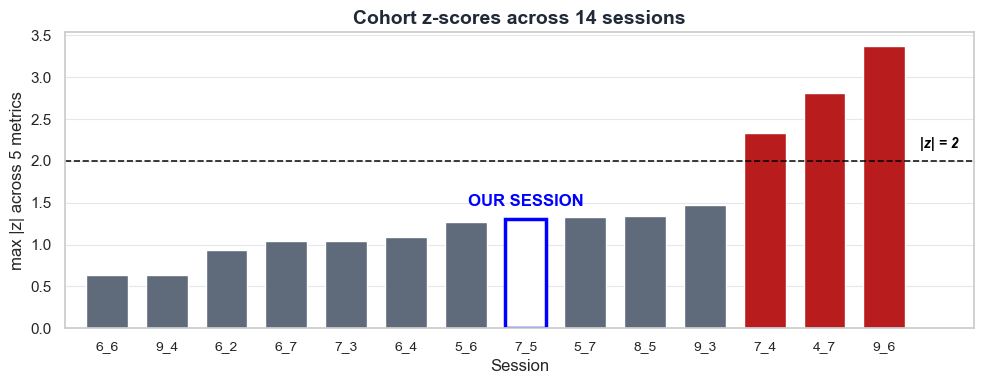

In [28]:
# Cohort z-scores across 14 sessions: bar chart for the presentation.
# Height per bar = max |z| across the 5 metrics from `flag_outlier_sessions`.
from neuro_palette import NEUTRAL, HIGHLIGHT, THRESHOLD

z_cols = [c for c in flagged.columns if c.startswith("z_")]
max_abs_z = flagged[z_cols].abs().max(axis=1).sort_values()
sessions = max_abs_z.index.tolist()

Z_THRESHOLD = 2.0
HIGHLIGHT_SESSION = "7_5"

fig, ax = plt.subplots(figsize=(10, 4))
for i, s in enumerate(sessions):
    h = max_abs_z[s]
    if s == HIGHLIGHT_SESSION:
        ax.bar(i, h, width=0.7, color="white",
               edgecolor="blue", linewidth=2.5)
    elif h > Z_THRESHOLD:
        ax.bar(i, h, width=0.7, color=THRESHOLD)
    else:
        ax.bar(i, h, width=0.7, color=NEUTRAL)

# Threshold line: dashed THRESHOLD red.
ax.axhline(Z_THRESHOLD, color="black", linestyle="--", linewidth=1.2, alpha=0.9)

# Extend x-axis right so the |z| = 2 label sits past the last bar.
ax.set_xlim(-0.7, len(sessions) + 0.5)

# |z| = 2 label, anchored on its left edge so it extends rightward.
ax.text(
    len(sessions) - 0.4, Z_THRESHOLD + 0.2, "|z| = 2",
    ha="left", va="center",
    fontsize=10, color="black", style="italic", fontweight="bold",
)

# 'OUR SESSION' centered above the highlighted bin.
if HIGHLIGHT_SESSION in sessions:
    idx = sessions.index(HIGHLIGHT_SESSION)
    ax.text(
        idx, max_abs_z[HIGHLIGHT_SESSION] + 0.12, "OUR SESSION",
        fontsize=12, fontweight="bold", color="blue",
        ha="center", va="bottom",
    )

# Horizontal grid only.
ax.yaxis.grid(True, color="#E5E7EB", linewidth=0.8)
ax.xaxis.grid(False)

ax.set_xticks(range(len(sessions)))
ax.set_xticklabels(sessions, fontsize=10)
ax.set_xlabel("Session")
ax.set_ylabel("max |z| across 5 metrics")
ax.set_title("Cohort z-scores across 14 sessions",
             fontsize=14, fontweight="bold")

fig.tight_layout()

# Raster for working/preview, vector for the slide deck.
PRESENTATION_DIR = FIGURES_DIR / "presentation"
PRESENTATION_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIGURES_DIR / "cohort_z_scores.png", dpi=150, bbox_inches="tight")
fig.savefig(PRESENTATION_DIR / "cohort_z_scores.svg",
            format="svg", bbox_inches="tight")
plt.show()

## Presentation figure: per-trial activity vs. running speed

Motivates the running-outlier removal: a small group of trials with high treadmill speed pulls the per-trial activity↔speed correlation strongly negative. Dropping them more than halves `|r|` and decouples the population signal from the running confound, leaving the bulk of the trials clustered near zero speed.

Saved to `figures/running_outlier_motivation.png`.

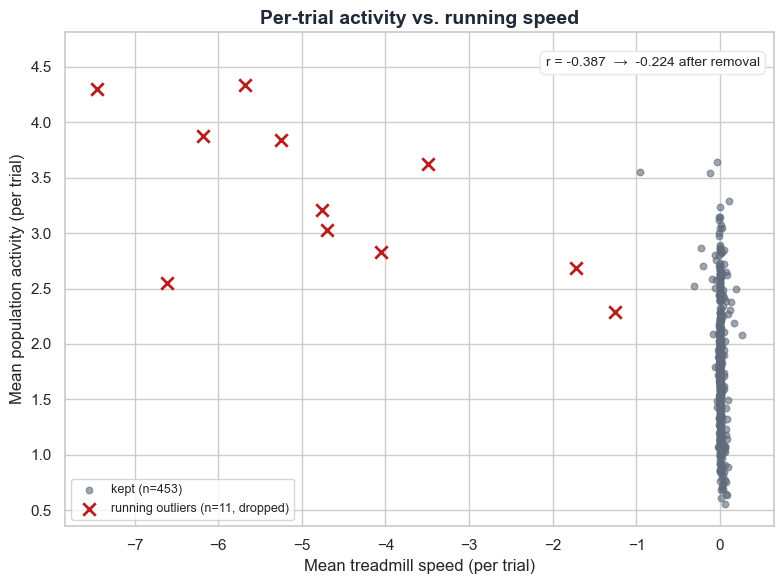

In [29]:
# Per-trial activity vs running speed: motivates the running-outlier removal.
from neuro_palette import NEUTRAL, THRESHOLD

keep = ~running_mask
r_full  = beh_align["mean_response"].corr(beh_align["mean_treadmill"])
r_clean = beh_align.loc[keep, "mean_response"].corr(beh_align.loc[keep, "mean_treadmill"])

fig, ax = plt.subplots(figsize=(8, 6))

# Bulk trials (kept).
ax.scatter(
    beh_align.loc[keep, "mean_treadmill"],
    beh_align.loc[keep, "mean_response"],
    s=22, color=NEUTRAL, alpha=0.6,
    label=f"kept (n={int(keep.sum())})",
)

# Running outliers: × marker, larger, THRESHOLD red.
ax.scatter(
    beh_align.loc[running_mask, "mean_treadmill"],
    beh_align.loc[running_mask, "mean_response"],
    s=80, marker="x", color=THRESHOLD, linewidths=2,
    label=f"running outliers (n={int(running_mask.sum())}, dropped)",
    zorder=5,
)

# In-plot annotation: r before vs after removal.
ax.text(
    0.98, 0.95,
    f"r = {r_full:+.3f}  →  {r_clean:+.3f} after removal",
    transform=ax.transAxes,
    ha="right", va="top",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="#E5E7EB"),
)

ax.axvline(0, color="#E5E7EB", linewidth=0.8, zorder=0)
ax.set_xlabel("Mean treadmill speed (per trial)")
ax.set_ylabel("Mean population activity (per trial)")
ax.set_title("Per-trial activity vs. running speed", fontsize=14, fontweight="bold")
ax.legend(loc="lower left", fontsize=9, frameon=True)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "running_outlier_motivation.png", dpi=150, bbox_inches="tight")
fig.savefig(PRESENTATION_DIR / "running_outlier_motivation.svg",
            format="svg", bbox_inches="tight")
plt.show()

## Presentation figure: drift across session

Companion to the running-speed scatter: per-trial mean population activity vs. trial index across the deep-dive session, with a linear fit overlay. The headline drop (~45% from start to end) is consistent with photobleaching of the calcium indicator over the session.

Saved to `figures/drift_across_session.png`. Same square footprint (6×6) as `running_outlier_motivation.png` so the two tile cleanly side-by-side in slides.

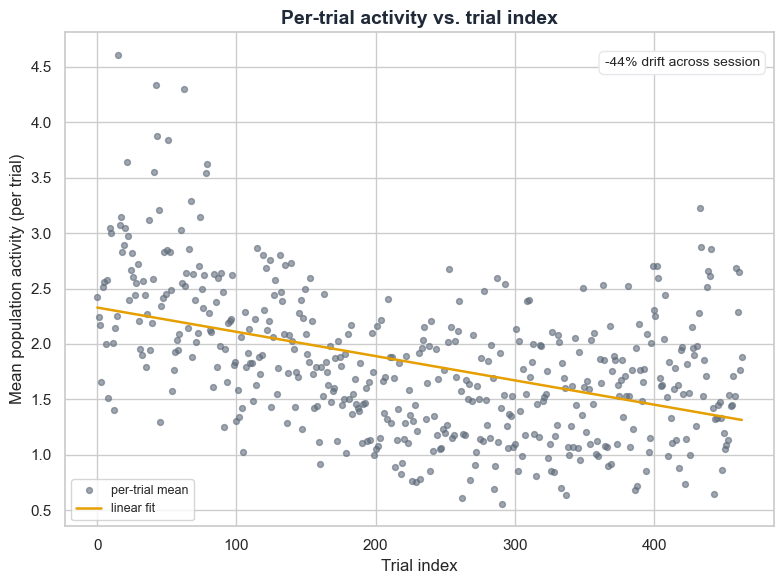

In [30]:
# Per-trial activity vs trial index: linear drift across the deep-dive session.
from neuro_palette import NEUTRAL, HIGHLIGHT

start_val = float(drift_df["trend"].iloc[0])
end_val   = float(drift_df["trend"].iloc[-1])
pct_drift = (end_val - start_val) / start_val * 100

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    drift_df.index, drift_df["mean_activity"],
    s=18, color=NEUTRAL, alpha=0.6,
    label="per-trial mean",
)
ax.plot(
    drift_df.index, drift_df["trend"],
    color=HIGHLIGHT, linewidth=1.8,
    label="linear fit",
)

# In-plot annotation: % drift, computed from the linear fit.
ax.text(
    0.98, 0.95,
    f"{pct_drift:+.0f}% drift across session",
    transform=ax.transAxes,
    ha="right", va="top",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="#E5E7EB"),
)

ax.set_xlabel("Trial index")
ax.set_ylabel("Mean population activity (per trial)")
ax.set_title("Per-trial activity vs. trial index", fontsize=14, fontweight="bold")
ax.legend(loc="lower left", fontsize=9, frameon=True)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "drift_across_session.png", dpi=150, bbox_inches="tight")
fig.savefig(PRESENTATION_DIR / "drift_across_session.svg",
            format="svg", bbox_inches="tight")
plt.show()

## Presentation figure: stimulus exemplars (Clip / Monet2 / Trippy)

Two-cell workflow for picking one example image per stim class for the slide deck:

- **Cell A (picker)**: rolls a random `(hash, frame)` per class and shows each   in its own single-panel preview, with the hash + frame index in the title.   Stores the rolls in `chosen_examples`. **Re-run as many times as you want**   until the rolls look good.
- **Cell B (saver)**: once you're happy, run this cell to write each chosen   frame to `figures/stim_examples/{class}.svg` as a raw image (no axes, no   title, transparent background, native pixel resolution). Cell B reads   `chosen_examples` from Cell A, so don't re-run Cell A between rolling and   saving.

Clip: 240 unique hashes available
Monet2: 20 unique hashes available
Trippy: 20 unique hashes available


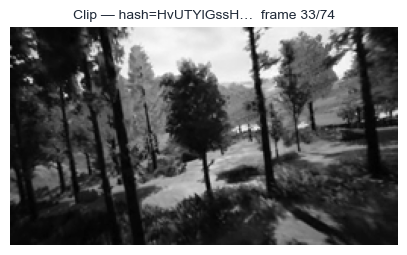

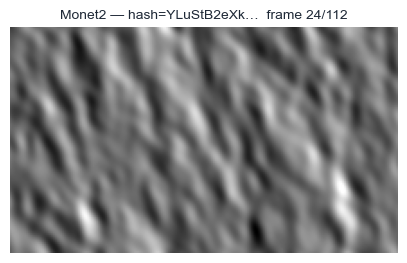

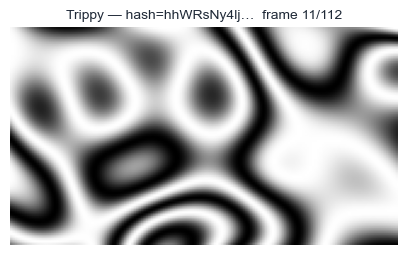


Rolls stored in `chosen_examples`. Run Cell B to save them.


In [31]:
# Cell A: random per-class picker. Re-run until you find rolls you like.
rng = np.random.default_rng()  # fresh randomness each run (ignores RANDOM_SEED).

CLASSES = ["Clip", "Monet2", "Trippy"]

# Group condition hashes by stim class.
hashes_by_class = {c: [h for h, t in deep_stim_map.items() if t == c] for c in CLASSES}
for c, hs in hashes_by_class.items():
    print(f"{c}: {len(hs)} unique hashes available")

# Roll a random (hash, frame) per class.
chosen_examples = {}
for cls in CLASSES:
    hs = hashes_by_class[cls]
    if not hs:
        print(f"  WARNING: no hashes for class {cls!r}, skipping")
        continue
    picked_hash = hs[int(rng.integers(0, len(hs)))]
    clip, _ = reader.get_video_data(picked_hash)
    if clip is None:
        print(f"  WARNING: video missing for {cls} hash={picked_hash[:10]}…, skipping")
        continue
    n_frames = clip.shape[0]
    picked_frame = int(rng.integers(0, n_frames))
    chosen_examples[cls] = {
        "hash": picked_hash,
        "frame_idx": picked_frame,
        "n_frames": n_frames,
        "image": clip[picked_frame],
    }

# Display each pick in its own single-panel preview.
for cls, info in chosen_examples.items():
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(info["image"], cmap="gray")
    ax.axis("off")
    ax.set_title(
        f"{cls}: hash={info['hash'][:10]}…  frame {info['frame_idx']}/{info['n_frames'] - 1}",
        fontsize=10,
    )
    plt.show()

print("\nRolls stored in `chosen_examples`. Run Cell B to save them.")

In [32]:
# Cell B: save the current rolls in `chosen_examples` as SVG.
# Raw image only: no axes, no title, transparent background, native pixel resolution.

SAVE_DIR = FIGURES_DIR / "stim_examples"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

"""for cls, info in chosen_examples.items():
    img = info["image"]
    h, w = img.shape

    # figsize × dpi matches source pixel dimensions → raster embedded at native res.
    dpi = 100
    fig = plt.figure(figsize=(w / dpi, h / dpi), dpi=dpi)
    ax = fig.add_axes([0, 0, 1, 1])  # axes fill the whole figure → no padding.
    ax.imshow(img, cmap="gray")
    ax.axis("off")

    out = SAVE_DIR / f"{cls.lower()}.svg"
    fig.savefig(out, transparent=True, format="svg", pad_inches=0)
    plt.close(fig)

    print(
        f"  wrote {out}  "
        f"(frame {info['frame_idx']}/{info['n_frames'] - 1} of hash {info['hash'][:12]}…)"
    )"""

'for cls, info in chosen_examples.items():\n    img = info["image"]\n    h, w = img.shape\n\n    # figsize × dpi matches source pixel dimensions → raster embedded at native res.\n    dpi = 100\n    fig = plt.figure(figsize=(w / dpi, h / dpi), dpi=dpi)\n    ax = fig.add_axes([0, 0, 1, 1])  # axes fill the whole figure → no padding.\n    ax.imshow(img, cmap="gray")\n    ax.axis("off")\n\n    out = SAVE_DIR / f"{cls.lower()}.svg"\n    fig.savefig(out, transparent=True, format="svg", pad_inches=0)\n    plt.close(fig)\n\n    print(\n        f"  wrote {out}  "\n        f"(frame {info[\'frame_idx\']}/{info[\'n_frames\'] - 1} of hash {info[\'hash\'][:12]}…)"\n    )'

## Presentation figure: Clip subclass exemplars (Cinematic / sports1m / Rendered)

Same two-cell workflow as the stim-class picker above, but rolls one example image **per Clip subclass** (`short_movie_name` from `/videos/.../attrs`).

- **Cell A (picker)**: rolls a random `(hash, frame)` per subclass and shows each   in its own single-panel preview. Re-run until the rolls look good. Stores them   in `chosen_subclass_examples`.
- **Cell B (saver)**: writes each chosen frame to   `figures/stim_examples/{subclass}.svg` (raw image, no axes/title, transparent,   native pixel resolution). Don't re-run Cell A between rolling and saving.

Cinematic: 704 unique Clip hashes available
sports1m: 704 unique Clip hashes available
Rendered: 704 unique Clip hashes available


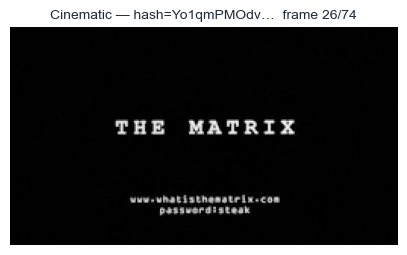

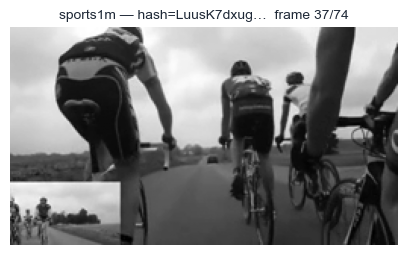

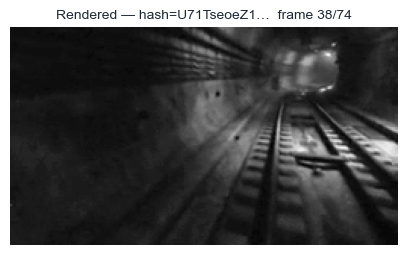


Rolls stored in `chosen_subclass_examples`. Run Cell B to save them.


In [44]:
# Cell A: random subclass picker (Clip subdivisions). Re-run until rolls look good.
import h5py

SUBCATEGORY_LIST = ["Cinematic", "sports1m", "Rendered"]
H5_PATH = DATADIR / "functional" / "microns_functional.h5"

# Build hash → short_movie_name for every Clip video in the H5.
hash_to_subcategory = {}
with h5py.File(H5_PATH, "r") as f:
    videos = f["videos"]
    for k in videos.keys():
        attrs = videos[k].attrs
        if attrs.get("type", "") != "Clip":
            continue
        if "short_movie_name" not in attrs:
            continue
        oh = attrs.get("original_hash", "")
        if isinstance(oh, bytes):
            oh = oh.decode("utf-8", "replace")
        sc_name = attrs["short_movie_name"]
        if isinstance(sc_name, bytes):
            sc_name = sc_name.decode("utf-8", "replace")
        hash_to_subcategory[oh] = sc_name

# Group hashes by subclass.
hashes_by_subclass = {sc: [] for sc in SUBCATEGORY_LIST}
for h, sc_name in hash_to_subcategory.items():
    if sc_name in hashes_by_subclass:
        hashes_by_subclass[sc_name].append(h)
for sc_name, hs in hashes_by_subclass.items():
    print(f"{sc_name}: {len(hs)} unique Clip hashes available")

# Roll a random (hash, frame) per subclass.
subclass_rng = np.random.default_rng()  # fresh randomness each run.
chosen_subclass_examples = {}
for sc_name in SUBCATEGORY_LIST:
    hs = hashes_by_subclass[sc_name]
    if not hs:
        print(f"  WARNING: no hashes for subclass {sc_name!r}, skipping")
        continue
    picked_hash = hs[int(subclass_rng.integers(0, len(hs)))]
    clip, _ = reader.get_video_data(picked_hash)
    if clip is None:
        print(f"  WARNING: video missing for {sc_name} hash={picked_hash[:10]}…, skipping")
        continue
    n_frames = clip.shape[0]
    picked_frame = int(subclass_rng.integers(0, n_frames))
    chosen_subclass_examples[sc_name] = {
        "hash": picked_hash,
        "frame_idx": picked_frame,
        "n_frames": n_frames,
        "image": clip[picked_frame],
    }

# Display each pick in its own single-panel preview.
for sc_name, info in chosen_subclass_examples.items():
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(info["image"], cmap="gray")
    ax.axis("off")
    ax.set_title(
        f"{sc_name}: hash={info['hash'][:10]}…  frame {info['frame_idx']}/{info['n_frames'] - 1}",
        fontsize=10,
    )
    plt.show()

print("\nRolls stored in `chosen_subclass_examples`. Run Cell B to save them.")

In [45]:
# Cell B: save the current subclass rolls in `chosen_subclass_examples` as SVG.
# Raw image only: no axes, no title, transparent background, native pixel resolution.

SAVE_DIR = FIGURES_DIR / "stim_examples"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

for sc_name, info in chosen_subclass_examples.items():
    img = info["image"]
    h, w = img.shape

    # figsize × dpi matches source pixel dimensions → raster embedded at native res.
    dpi = 100
    fig = plt.figure(figsize=(w / dpi, h / dpi), dpi=dpi)
    ax = fig.add_axes([0, 0, 1, 1])
    ax.imshow(img, cmap="gray")
    ax.axis("off")

    out = SAVE_DIR / f"{sc_name.lower()}.svg"
    fig.savefig(out, transparent=True, format="svg", pad_inches=0)
    plt.close(fig)

    print(
        f"  wrote {out}  "
        f"(frame {info['frame_idx']}/{info['n_frames'] - 1} of hash {info['hash'][:12]}…)"
    )

  wrote figures/stim_examples/cinematic.svg  (frame 26/74 of hash Yo1qmPMOdvfQ…)
  wrote figures/stim_examples/sports1m.svg  (frame 37/74 of hash LuusK7dxug4y…)
  wrote figures/stim_examples/rendered.svg  (frame 38/74 of hash U71TseoeZ1Qq…)
